<a href="https://www.kaggle.com/code/vladosht/simple-stock-pricing-model?scriptVersionId=269694878" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

This notebook will present a model which attempts to make individual estimates whether a stock is overvalued or not. It is based on the fundamental financial data of 3000+ public companies, which report to the SEC and which are currently traded on US stock exchanges.

DISCLAIMER: The results of this model must not in any way be interpreted as financial advice. It is intended for research purposes only and no investment decisions must be made based on it.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch
import multiprocessing as mp
import json
pd.set_option('display.max_rows', 200)
# Workaround for a pandas bug, as described here:
# https://stackoverflow.com/questions/30519487/pandas-error-invalid-value-encountered
pd.set_option('display.float_format', lambda x:'%f'%x)

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print('Torch threads:',torch.get_num_threads())
print(torch.ones(1, device=device),device)

Torch threads: 2
tensor([1.], device='cuda:0') cuda


In [3]:
if __name__ == '__main__':
    mp.set_start_method('fork')
print('{} CPUs available'.format(mp.cpu_count()))
max_jobs = mp.cpu_count() + 1

4 CPUs available


The model will be based on the following features and labels, taken from the SEC fundamentals dataset:

In [4]:
ml_features = ['Assets','Liabilities','NetCashOperating_ttm']
ml_label = 'price'
keys = ['snapshot','cik','date']
window_size = 12*3 #in number of snapshots

The model is called "simple", because it is rooted in this very basic assumption:  
Market_Capitalization = ( Assets \* asset_multiplier - Liabilities + NetCashOperating_ttm \* cash_multiplier ) \* hype + bias  
The business logic behind this formula is that the market capitalization of a company is dependent on its current static value (its equity) and its future cashflows. The following considerations apply:  
1. We assume the total assets of an individual company should never be taken at the nominal value that appears on the balance sheet, because they often contain significant amount of "intangible" assets, for which it is notoriously difficult to arrive at a fair value. Therefore, we discount them with an asset_multiplier.
2. The Liabilities, on the other hand, can be taken at nominal value, because it is a rare event for any kind of debt, accounts payable or the like, to be written off.
3. Then, the cash flows from operating activities can be modeled as a [perpetuity](https://en.wikipedia.org/wiki/Perpetuity). This is inspired by the idea for a [Steady State Cash Flow Model](https://www.google.com/search?q=%22Steady+State+Cash+Flow+Model%22) where we attempt to estimate the fair value of a company on the assumption that its business behaves the same way for the foreseeable future. In essence, we again discount the NetCashOperating_ttm with a cash_multiplier. We use the Trailing Twelve Months (ttm) value here, and not the quarterly value, because it smoothens any seasonalities and makes the model less erratic.
4. All of the above is multiplied by a "hype" parameter, which is the premium or penalty that the market gives to the total value of the company.
5. The bias further fine-tunes the company value to its market capitalization.  

However, it seems difficult to obtain freely available historic market capitalization data for individual companies. It turns out this is not really necessary. It is much easier to obtain historic prices and modelling the share price directly is even simpler.  
We do this by maximizing the **correlation coefficient** between our formula and the price. In short, we try to find such asset_multiplier and cash_multiplier parameters, for which the correlation between ( Assets \* asset_multiplier - Liabilities + NetCashOperating_ttm \* cash_multiplier ) and the price is equal to 1.

In [5]:
# We use this dataset to provide ticker descriptions later on.
with open('/kaggle/input/sec-edgar-cik-ticker-exchange/company_tickers_exchange.json',mode='rt') as f:
    jfile = json.load(f)
tickers = pd.DataFrame(columns=jfile['fields'],data=jfile['data'],dtype=str)
tickers = tickers[tickers['exchange']!='OTC'].dropna() #leave only tickers traded on an exchange
tickers['exchange'] = tickers['exchange'].str.upper().str.strip()
tickers['cik'] = tickers['cik'].str.zfill(10)
tickers['len'] = 4
tickers.loc[tickers[tickers['ticker'].str.contains('-')].index,'len'] += 1
tickers['ticker'] = tickers.apply(lambda row: str(row.ticker[:row.len]),axis='columns').str.rstrip().str.rstrip('-').str.upper()
tickers = tickers.sort_values(by=['cik','exchange','ticker']).drop_duplicates(subset=['cik'],keep='last').set_index('cik').drop(columns=['len'])
tickers

,name,ticker,exchange
cik,,,
0000001750,AAR CORP,AIR,NYSE
0000001800,ABBOTT LABORATORIES,ABT,NYSE
0000002098,ACME UNITED CORP,ACU,NYSE
0000002178,"ADAMS RESOURCES & ENERGY, INC.",AE,NYSE
0000002186,BK Technologies Corp,BKTI,NYSE
...,...,...,...
0001984060,Atlas Energy Solutions Inc.,AESI,NYSE
0001990550,"Ambrx Biopharma, Inc.",AMAM,NASDAQ
0001993004,"NorthWestern Energy Group, Inc.",NWE,NASDAQ


In [6]:
prices = pd.read_csv('/kaggle/input/monthly-us-stock-prices/prices.csv').rename(columns={'date':'snapshot'}).dropna()
prices['snapshot'] = pd.to_datetime(prices['snapshot']).dt.date
prices

,ticker,exchange,snapshot,price
0,A,NYSE - Delayed Quote,2010-02-01,20.050000
1,A,NYSE - Delayed Quote,2010-03-01,22.500000
2,A,NYSE - Delayed Quote,2010-04-01,24.600000
3,A,NYSE - Delayed Quote,2010-05-01,25.940000
4,A,NYSE - Delayed Quote,2010-06-01,23.150000
...,...,...,...,...
602887,ZYXI,NasdaqGS - Delayed Quote,2025-07-01,2.580000
602888,ZYXI,NasdaqGS - Delayed Quote,2025-08-01,2.230000
602889,ZYXI,NasdaqGS - Delayed Quote,2025-09-01,1.640000
602890,ZYXI,NasdaqGS - Delayed Quote,2025-10-01,1.450000


In [7]:
raw_snapshots = pd.read_csv('/kaggle/input/fundamental-data-from-sec-xbrl-companyfacts-zip/snapshots.csv',dtype={'cik':str})
for i in ['snapshot','date']:
    raw_snapshots[i] = pd.to_datetime(raw_snapshots[i]).dt.date
raw_snapshots['timediff'] = pd.to_timedelta((raw_snapshots['snapshot'] - raw_snapshots['date'])).dt.days
raw_snapshots

,snapshot,cik,date,Assets,Revenue,COGS,GrossProfit,Equity,NetCashOperating,NetCashFinancing,...,Revenue_ttm,GrossProfit_ttm,NetCashOperating_ttm,NetCashFinancing_ttm,Earnings_ttm,ticker,exchange,PublicFloat,Employees,timediff
0,2012-01-01,0000001750,2011-11-30,1.821612,0.482000,0.403400,0.078600,0.863948,0.030412,-0.006559,...,1.920517,0.322328,0.083588,0.026485,0.073512,AIR,NYSE,0.934568,NaN,32
1,2012-01-01,0000001800,2011-09-30,59.628176,9.816682,3.973250,5.843432,24.603800,3.054430,-2.668122,...,38.441677,22.693948,9.885247,-4.831951,4.550604,ABT,NYSE,69.683329,NaN,93
2,2012-01-01,0000001961,2011-09-30,NaN,0.000000,0.000000,0.000000,NaN,-0.000067,0.000150,...,0.000188,0.000169,-0.000528,0.000456,-0.000968,NaN,NaN,NaN,NaN,93
3,2012-01-01,0000002034,2011-09-30,0.292355,0.101317,0.082798,0.018519,0.161372,0.005913,-0.001570,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,93
4,2012-01-01,0000002098,2011-09-30,0.055344,0.019036,0.012396,0.006640,0.027561,0.003165,-0.000680,...,0.093494,0.033742,-0.003533,0.008428,0.004770,ACU,NYSE,NaN,NaN,93
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1073377,2025-10-18,0002070900,2025-06-30,0.000214,NaN,NaN,NaN,-0.000006,0.000018,-0.000074,...,NaN,NaN,NaN,NaN,NaN,QUMS,NASDAQ,NaN,NaN,110
1073378,2025-10-18,0002071489,2025-06-30,0.000023,0.000008,NaN,NaN,0.000001,0.000005,0.000002,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,110
1073379,2025-10-18,0002072421,2025-06-30,0.299060,0.010650,NaN,NaN,0.023755,0.000041,0.018063,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,110
1073380,2025-10-18,0002073928,2025-06-30,0.000259,NaN,NaN,NaN,-0.000020,NaN,0.000000,...,NaN,NaN,NaN,NaN,NaN,MBVI,NASDAQ,NaN,NaN,110


Below we merge the fundamental data with the price data and do some dataset cleaning to maximize model performance. The datasets themselves are documented on their respective pages and you can refer to them for further insights about their structure.

In [8]:
snapshots = pd.merge(raw_snapshots,prices,on=['ticker','snapshot'],suffixes=('','_yahoo'),how='left')

# The key date (snapshot date) must always be later than the period-end date. We enforce this
# per cik using the timediff column - it must be positive for all records of a cik.
# We also ensure a window_size number of snapshots of historic data is available for each cik.
snapshots = snapshots[keys +['ticker'] + ml_features + [ml_label] + ['timediff']]
valid_ciks = snapshots.dropna().groupby(by='cik')['timediff'].aggregate(['min','count'])
valid_ciks = valid_ciks[(valid_ciks['min']>0)&(valid_ciks['count']>window_size)]
snapshots = snapshots.set_index(keys)
snapshots = snapshots.loc[(slice(None),valid_ciks.index.to_list()),:].sort_index().drop(columns='timediff')

# Ciks that have assets close to zero cause problems during training. We remove them
zero_asset_ciks = list(snapshots[snapshots['Assets'].fillna(0.0).abs()<1e-3].reset_index()['cik'].unique())
zero_asset_ciks = snapshots.loc[(slice(None),zero_asset_ciks),:].index
snapshots = snapshots.drop(index=zero_asset_ciks)

# There are several ciks, that have reported wrong data 1000 times larger than actual.
# They apparently never submitted a correction.
# This data disrupts the training and we remove the whole ciks.
asset_outliers = snapshots.groupby(by='cik')['Assets'].aggregate(['min','max'])
asset_outliers = asset_outliers['min']/asset_outliers['max']
asset_outliers = asset_outliers.sort_values().fillna(0.0)
asset_outliers = list(asset_outliers[asset_outliers<1e-3].reset_index()['cik'].unique())
asset_outliers = snapshots.loc[(slice(None),asset_outliers),:].index
snapshots = snapshots.drop(index=asset_outliers)
snapshots

ticker    Assets  Liabilities  \
snapshot   cik        date                                       
2012-01-01 0000001750 2011-11-30    AIR  1.821612     0.957664   
           0000001800 2011-09-30    ABT 59.628176    35.024376   
           0000002098 2011-09-30    ACU  0.055344     0.027783   
           0000002488 2011-10-01    AMD  5.236000     3.492000   
           0000002969 2011-09-30    APD 14.290700     8.494900   
...                                 ...       ...          ...   
2025-10-18 0001894954 2025-06-30   XPON  0.008605     0.006538   
           0001901637 2025-06-30   USCB  2.719474     2.487891   
           0001902733 2025-07-31   NCNO  1.616017     0.559199   
           0001914605 2025-06-30   ECBK  1.515014     1.346737   
           0001915657 2025-06-30   DINO 16.843000     7.561000   

                                  NetCashOperating_ttm     price  
snapshot   cik        date                                        
2012-01-01 0000001750 2011-11-30              0.083588 19.170000  
           0000001800 2011-09-30              9.885247 26.980000  
           0000002098 2011-09-30             -0.003533  9.500000  
           0000002488 2011-10-01             -0.018000  5.400000  
           0000002969 2011-09-30              1.753200 78.810000  
...                                                ...       ...  
2025-10-18 0001894954 2025-06-30             -0.007786  1.520000  
           0001901637 2025-06-30              0.040351 16.950000  
           0001902733 2025-07-31              0.067814 23.760000  
           0001914605 2025-06-30              0.006604 14.940000  
           0001915657 2025-06-30              1.067000 51.860000  

[453784 rows x 5 columns]

Machine learning algorithms in general cannot handle NaN values. The data we feed into our algorithm later must not only be free of NaNs, but it must also be symmetrical, i.e., for each cik there must be the same number of snapshots in the dataset. This is of course not the case in the raw data, so we create rows where they do not exist for a particular cik/snapshot combination. Then we replace all NaNs with zero, but we do retain information in a new column (is_created) whether a row was artificially created or not.

In [9]:
ml_input_df = snapshots.dropna().copy()
ml_input_df['is_created'] = False
unique_snapshot_dates = ml_input_df.index.get_level_values(0).unique().sort_values().to_series()
unique_ciks = ml_input_df.index.get_level_values(1).unique().sort_values().to_series()
print("There are {} unique snapshots and {} unique ciks for a total of {} records.".format(len(unique_snapshot_dates),len(unique_ciks),len(unique_snapshot_dates)*len(unique_ciks)))

ml_input_df = pd.merge(pd.merge(unique_snapshot_dates, unique_ciks, how='cross'),ml_input_df[ml_features+[ml_label,'is_created']].reset_index(drop=False),how='left')
ml_input_df = ml_input_df.drop(columns=['date']).set_index(['cik','snapshot']).sort_index()
ml_input_df['is_created'] = ml_input_df['is_created'].isna()
ml_input_df = ml_input_df.fillna(0.0)
ml_input_df

There are 167 unique snapshots and 3440 unique ciks for a total of 574480 records.


Assets  Liabilities  NetCashOperating_ttm     price  \
cik        snapshot                                                            
0000001750 2012-01-01  1.821612     0.957664              0.083588 19.170000   
           2012-02-01  1.821612     0.957664              0.083588 21.190000   
           2012-03-01  1.821612     0.957664              0.083588 22.050000   
           2012-04-01  2.220293     1.330213              0.066898 18.250000   
           2012-05-01  2.220293     1.330213              0.066898 15.450000   
...                         ...          ...                   ...       ...   
0001915657 2025-07-01 16.542000     7.355000              0.704000 41.080000   
           2025-08-01 16.843000     7.561000              1.067000 43.940000   
           2025-09-01 16.843000     7.561000              1.067000 50.880000   
           2025-10-01 16.843000     7.561000              1.067000 52.340000   
           2025-10-18 16.843000     7.561000              1.067000 51.860000   

                       is_created  
cik        snapshot                
0000001750 2012-01-01       False  
           2012-02-01       False  
           2012-03-01       False  
           2012-04-01       False  
           2012-05-01       False  
...                           ...  
0001915657 2025-07-01       False  
           2025-08-01       False  
           2025-09-01       False  
           2025-10-01       False  
           2025-10-18       False  

[574480 rows x 5 columns]

The cell below is the heart of our machine learning model. The following is critical for the loss function we want to use - the correlation coefficient between our model formula and the price. Unfortunately the built-in PyTorch function can handle only pairs of 1d tensors, so with the help of Gemini we re-created it to handle our multi-dimensional data.

In [10]:
# Generated by Gemini AI
def batched_corrcoef(t1, t2):
    """
    Computes batched correlation coefficient matrix.
    t1 and t2 are tensors of shape (B, N) where B is the batch size
    and N is the number of observations.
    Returns a tensor of shape (B, 2, 2).
    """
    # Stack the tensors along a new dimension to create a (B, 2, N) tensor
    stacked_tensors = torch.stack([t1, t2], dim=1)

    # Compute covariance for each batch
    # We need to compute covariance for each item in the batch.
    # torch.cov doesn't have a batch dimension argument.
    # We can implement batched covariance manually.
    mean_x = torch.mean(stacked_tensors, dim=2, keepdim=True)
    mx = stacked_tensors - mean_x
    # For batched dot product, we can use matmul
    # mx is (B, 2, N), mx.transpose(-1, -2) is (B, N, 2)
    # cov is (B, 2, 2)
    cov_matrix = torch.matmul(mx, mx.transpose(-1, -2)) / (stacked_tensors.size(2) - 1)

    # Extract diagonal for standard deviation
    std_dev = torch.sqrt(torch.diagonal(cov_matrix, dim1=-2, dim2=-1))
    # std_dev is (B, 2). We need to compute outer product for each batch item.
    # We can do this by unsqueezing and multiplying.
    std_dev_prod = std_dev.unsqueeze(2) * std_dev.unsqueeze(1)

    # Normalize covariance matrix
    corr_matrix = cov_matrix / std_dev_prod
    return corr_matrix

# Create two sample tensors
t1 = torch.randn(10, 5)
t2 = torch.randn(10, 5)

# Compute batched correlation coefficient
result_vectorized = batched_corrcoef(t1, t2)

print("Shape of the vectorized result:", result_vectorized.shape)
print("Result for the first batch item (vectorized):\n", result_vectorized[0])

Shape of the vectorized result: torch.Size([10, 2, 2])
Result for the first batch item (vectorized):
 tensor([[ 1.0000, -0.1590],
        [-0.1590,  1.0000]])


In [11]:
# The correlation coefficient varies from 0 (no correlation) to 1 (perfect correlation)
# In order to be used as a part of a loss function, we have to convert this in a way
# that 0 means perfect correlation.
def convert_corrcoef_to_loss(corrcoef):
    """
    Takes a tensor of shape (B, 2, 2).
    """
    return 2 - corrcoef.sum(dim=[1,2])/2

What follows is the actual model implementation. We need to clarify several things here.
1. We compute the asset_multiplier on per-cik, per-snapshot basis, but the cash_multiplier is only computed on per-snapshot basis. The reasoning behind this is that it is much more logical to assume that the discount rate for the NetCashOperating_ttm is the same for all ciks on a given date, something like a common interest rate for all companies that depends not on individual companies, but on general interest and inflation levels and return-on-investment expectations of investors. This also makes the model more generalized.
2. The asset_multiplier is enforced to be always positive by exponentiating the actual parameter we are trying to find. I.e., final asset_multiplier = 10 \*\* (internal parameter)
3. From our previous [whole-market model](https://www.kaggle.com/code/vladosht/s-p-500-fundamental-data-model) we know that the market as a whole does not adjust the total assets away from their nominal value. We put this knowledge into the loss function by minimizing the ratio between total adjusted assets for all ciks and total unadjusted assets for all ciks (method get_asset_loss)
4. Finally, the model results are returned by the get_df method, which simply takes the input dataframe and extends it with two additional columns for the asset_multiplier and cash_multiplier. It also returns a column for the computed model value. Remember, this model value only correlates perfectly with the price, it is not equal to the price.

In [12]:
class SimplePricingModel(torch.nn.Module):
    def __init__(self,df):
        super().__init__()
        self.df          = df
        self.columns     = df.columns.to_list()
        self.columns     = { i:self.columns.index(i) for i in self.columns }
        self.len_ciks    = len(df.index.get_level_values(0).unique())
        self.len_snapshots = len(df.index.get_level_values(1).unique())
        self.asmul       = torch.nn.Parameter(0.1 + torch.rand(self.len_ciks,self.len_snapshots))
        self.cashmul     = torch.nn.Parameter(0.1 + torch.rand(self.len_snapshots))
        self.ml_input    = torch.nn.Buffer(torch.tensor(df[ml_features].to_numpy()).reshape(self.len_ciks,self.len_snapshots,-1))
        self.labels      = torch.nn.Buffer(torch.tensor(df[ml_label].to_numpy()).reshape(self.len_ciks,self.len_snapshots))
        self.print_shape = True
        print('Input shape:',self.ml_input.shape)
        print('Labels shape:',self.labels.shape)
        print('Asset multiplier shape:',self.asmul.shape)
        print('Cash multiplier shape:',self.cashmul.shape)

    def get_adjusted_assets(self):
        adjusted_assets = self.ml_input[:,:,self.columns['Assets']] * 10**self.asmul
        if self.print_shape:
            print('Adjusted assets shape:',adjusted_assets.shape)        
        return adjusted_assets

    def get_asset_loss(self):
        # 1d tensor of length self.len_snapshots
        asset_loss = (self.get_adjusted_assets().sum(dim=0)/self.ml_input[:,:,self.columns['Assets']].sum(dim=0)-1)**2
        if self.print_shape:
            print('Asset loss shape:',asset_loss.shape)        
        return asset_loss
    
    def get_total_loss(self):
        y_pred = self()
        corrcoef = batched_corrcoef(y_pred,self.labels)
        if self.print_shape:
            print('Predictions shape:',y_pred.shape)
            print('Labels shape:',self.labels.shape)
            print('Correlation coefficient shape:',corrcoef.shape)
        corrcoef = convert_corrcoef_to_loss(corrcoef)
        total_loss = corrcoef.sum() + corrcoef.std()
        # We need regularization for the asset_multiplier, otherwise the values become uncomparable across ciks
        total_loss += 100 * (self.asmul.mean()**2)**0.5 + 10 * self.asmul.std()
        total_loss += self.get_asset_loss().sum()
        if self.print_shape:
            self.print_shape = False
        return total_loss

    def get_param_state(self):
        return { "median cashmul" : self.cashmul.median().item(), "median asmul" : (10 ** self.asmul).median().item() }

    def forward(self):
        fwd = self.get_adjusted_assets()
        fwd -= self.ml_input[:,:,self.columns['Liabilities']]
        fwd += self.ml_input[:,:,self.columns['NetCashOperating_ttm']] * self.cashmul.unsqueeze(0)
        if self.print_shape:
            print('Forward shape:',fwd.shape)
        return fwd

    def get_df(self):
        ret_df = self.df.copy()
        asmul = pd.Series(index=self.df.index,data = self.asmul.reshape(-1).cpu().detach().numpy()).rename('asmul')
        asmul = 10**asmul
        cashmul = self.cashmul.cpu().detach().numpy()
        cashmul = pd.Series(index=self.df.index.get_level_values(1).unique().sort_values(), data=cashmul).rename('cashmul')

        ret_df = pd.merge(ret_df,asmul,left_index=True,right_index=True)
        ret_df = pd.merge(ret_df,cashmul,left_index=True,right_index=True)
        ret_df['model'] = self.forward().reshape(-1).cpu().detach().numpy()
        return ret_df

def model_train(model, num_epochs = 200000, epoch_batch = 1000):
    optimizer = torch.optim.Adagrad(params = model.parameters(), lr = 0.15)

    output_graphic = []

    for epoch in range(num_epochs):
        optimizer.zero_grad()
        loss = model.get_total_loss()
        loss.backward()
        optimizer.step()
        if (epoch+1) % epoch_batch == 0:
            param_state = list(model.get_param_state().items())
            output_string = f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.8f}, "
            output_string += " ".join([f"{key}: {value:.8f};" for key,value in param_state])
            print(output_string)
            output_graphic.append({'loss':loss.item(),param_state[0][0]:param_state[0][1]})
        
    output_graphic = pd.DataFrame(output_graphic)
    output_graphic['loss'].plot(grid=True,figsize=(20,5),legend=True,title='Epoch progression')
    output_graphic[output_graphic.columns[1]].plot(secondary_y=True,legend=True,grid=False)
    plt.show()
pricing_model = SimplePricingModel(ml_input_df).to(device)
print(pricing_model.ml_input.device)

Input shape: torch.Size([3440, 167, 3])
Labels shape: torch.Size([3440, 167])
Asset multiplier shape: torch.Size([3440, 167])
Cash multiplier shape: torch.Size([167])
cuda:0


Adjusted assets shape: torch.Size([3440, 167])
Forward shape: torch.Size([3440, 167])
Predictions shape: torch.Size([3440, 167])
Labels shape: torch.Size([3440, 167])
Correlation coefficient shape: torch.Size([3440, 2, 2])
Adjusted assets shape: torch.Size([3440, 167])
Asset loss shape: torch.Size([167])
Epoch [1000/200000], Loss: 6.79402728, median cashmul: 1.00381196; median asmul: 1.22922719;
Epoch [2000/200000], Loss: 4.61455030, median cashmul: 0.93176007; median asmul: 1.09400403;
Epoch [3000/200000], Loss: 3.48383908, median cashmul: 0.89640659; median asmul: 1.01033485;
Epoch [4000/200000], Loss: 2.78969164, median cashmul: 0.81285608; median asmul: 0.95448428;
Epoch [5000/200000], Loss: 2.42003410, median cashmul: 0.77292609; median asmul: 0.91844672;
Epoch [6000/200000], Loss: 2.19269919, median cashmul: 0.75140840; median asmul: 0.90149277;
Epoch [7000/200000], Loss: 1.99577337, median cashmul: 0.74107969; median asmul: 0.89413458;
Epoch [8000/200000], Loss: 1.88807761, medi

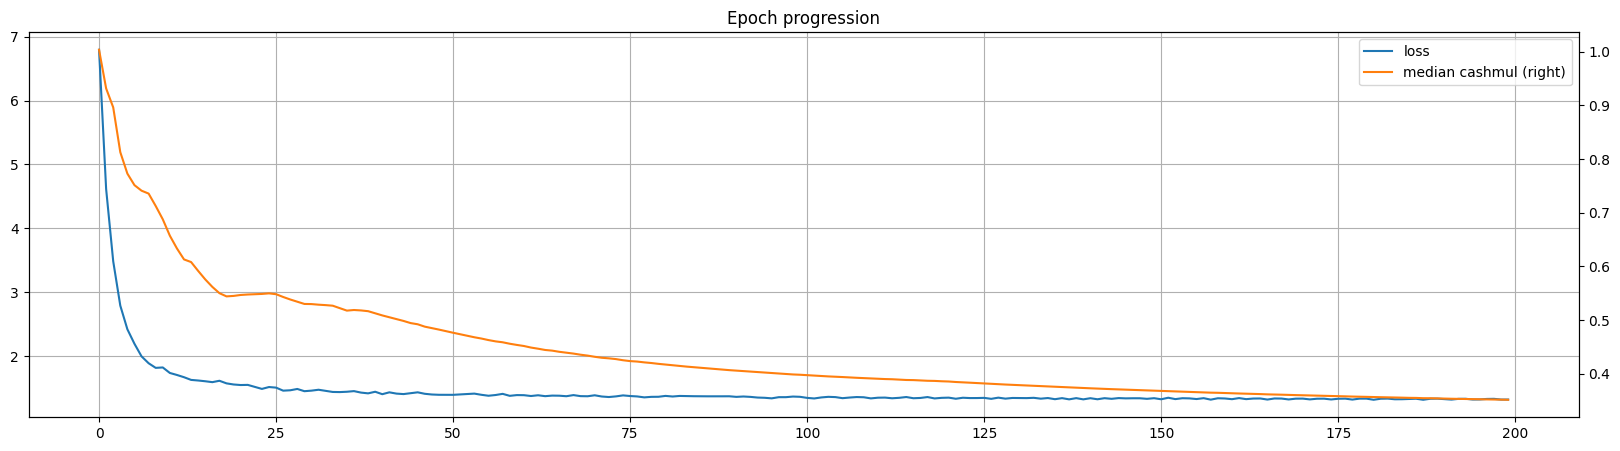

Assets  Liabilities  NetCashOperating_ttm     price  \
cik        snapshot                                                            
0000001750 2012-01-01  1.821612     0.957664              0.083588 19.170000   
           2012-02-01  1.821612     0.957664              0.083588 21.190000   
           2012-03-01  1.821612     0.957664              0.083588 22.050000   
           2012-04-01  2.220293     1.330213              0.066898 18.250000   
           2012-05-01  2.220293     1.330213              0.066898 15.450000   
...                         ...          ...                   ...       ...   
0001915657 2025-07-01 16.542000     7.355000              0.704000 41.080000   
           2025-08-01 16.843000     7.561000              1.067000 43.940000   
           2025-09-01 16.843000     7.561000              1.067000 50.880000   
           2025-10-01 16.843000     7.561000              1.067000 52.340000   
           2025-10-18 16.843000     7.561000              1.067000 51.860000   

                         asmul   cashmul     model  
cik        snapshot                                 
0000001750 2012-01-01 0.969127 -0.183377  0.792381  
           2012-02-01 0.981244 -0.181273  0.814629  
           2012-03-01 0.984450 -0.148673  0.823194  
           2012-04-01 0.956827 -0.163880  0.783259  
           2012-05-01 0.943082 -0.173879  0.752073  
...                        ...       ...       ...  
0001915657 2025-07-01 1.034639  0.513604 10.121577  
           2025-08-01 1.058846  0.514346 10.821956  
           2025-09-01 1.158778  0.538681 12.531066  
           2025-10-01 1.179345  0.549950 12.889503  
           2025-10-18 1.173738  0.528058 12.771708  

[438673 rows x 7 columns]

In [13]:
model_train(pricing_model)
model_output = pricing_model.get_df()
model_output = model_output[~model_output['is_created']].drop(columns=['is_created'])
model_output

In [14]:
# We take the computed multipliers and put them into the original dataframe "snapshots"
mul_columns = ['asmul','cashmul']
result = pd.merge(snapshots,model_output.groupby(by=['snapshot','cik'])[mul_columns].mean(),left_index=True,right_index=True,how='left')
result['model'] = result['asmul']*result['Assets'] - result['Liabilities'] + result['cashmul']*result['NetCashOperating_ttm']
# Sample data: Amazon
result[result['ticker']=='AMZN'].tail(20)

,,,ticker,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model
snapshot,cik,date,,,,,,,,
2024-04-01,0001018724,2023-12-31,AMZN,527.854000,325.979000,133.367167,180.380000,0.803387,0.335964,142.898781
2024-05-01,0001018724,2023-12-31,AMZN,527.854000,325.979000,133.367167,175.000000,0.787240,0.369459,138.842412
2024-06-01,0001018724,2024-03-31,AMZN,530.969000,314.308000,159.120667,176.440000,0.730022,0.418184,139.852735
2024-07-01,0001018724,2024-03-31,AMZN,530.969000,314.308000,159.120667,193.250000,0.752747,0.427676,153.429380
2024-08-01,0001018724,2024-03-31,AMZN,530.969000,314.308000,159.120667,186.980000,0.732219,0.463651,148.253858
2024-09-01,0001018724,2024-06-30,AMZN,554.818000,318.371000,177.090000,178.500000,0.678765,0.470308,141.506848
2024-10-01,0001018724,2024-06-30,AMZN,554.818000,318.371000,177.090000,186.330000,0.681057,0.498505,147.771804
2024-11-01,0001018724,2024-06-30,AMZN,554.818000,318.371000,177.090000,186.400000,0.687917,0.477447,147.848862
2024-12-01,0001018724,2024-09-30,AMZN,584.626000,325.475000,193.943333,207.890000,0.657801,0.546071,164.999217


In [15]:
# Let's see for how many ciks the achieved correlation is perfect and for how many it is not.
model_corr = result.dropna().groupby(by='cik')[[ml_label,'model']].corr().reset_index()
model_corr = model_corr[model_corr[model_corr.columns[1]]==ml_label][['cik','model']].rename(columns={'model':'corrcoef'}).set_index('cik')
model_corr.sort_values(by='corrcoef').round(3).value_counts()

corrcoef
1.000000    3434
0.999000       6
Name: count, dtype: int64

It is interesting to see the development of the two multipliers over time. The cash multiplier is the same for all ciks on a given snapshot date and can probably serve as some form of valuation metric for the whole market.

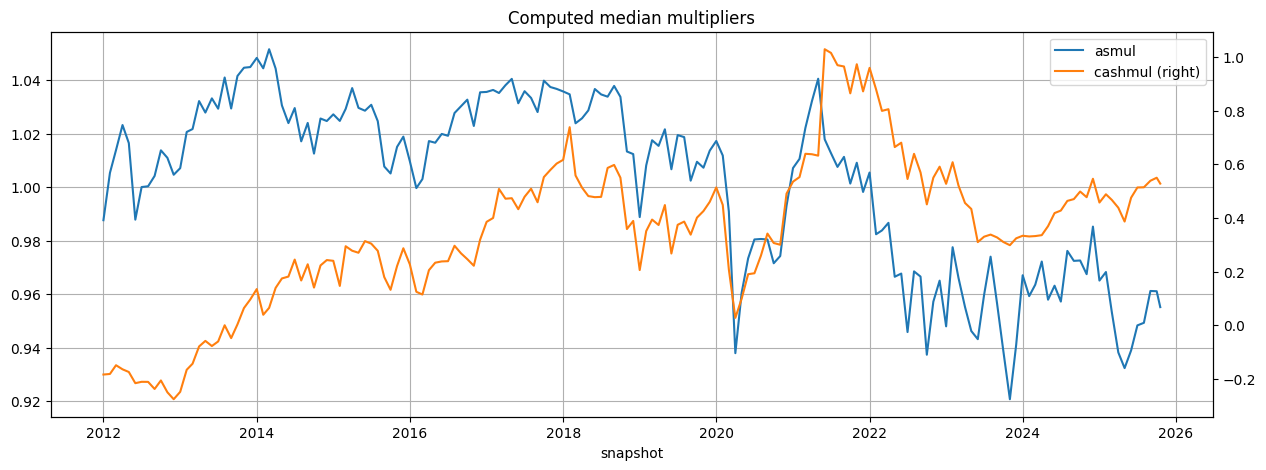

Median asset_multiplier per cik: 0.9978209733963013
Median asset_multiplier per snapshot: 1.011293888092041


In [16]:
mul_graph = result.groupby(by='snapshot')[mul_columns].median()
mul_graph['asmul'].plot(title='Computed median multipliers',figsize=(15,5),grid=True,legend=True)
mul_graph['cashmul'].plot(secondary_y=True,legend=True,grid=False)
plt.show()
print("Median asset_multiplier per cik:",result['asmul'].groupby(by=['cik']).median().median())
print("Median asset_multiplier per snapshot:",result['asmul'].groupby(by=['snapshot']).median().median())

We can now output the results for later use in other models/notebooks/datasets

In [17]:
result.to_csv('/kaggle/working/pricing_model.csv.gz')

Finally, we apply the model to individual ciks. We have tried to make the selection of sample tickers as varied as possible in terms of company kinds and sizes. By following the development of the asset_multiplier of each company over time, we can make some estimates if and how much the stock price corresponds to the financial fundamentals.

In other words, we may be able to determine if a stock is relatively over-or-undervalued, compared to its historic fundamentals.

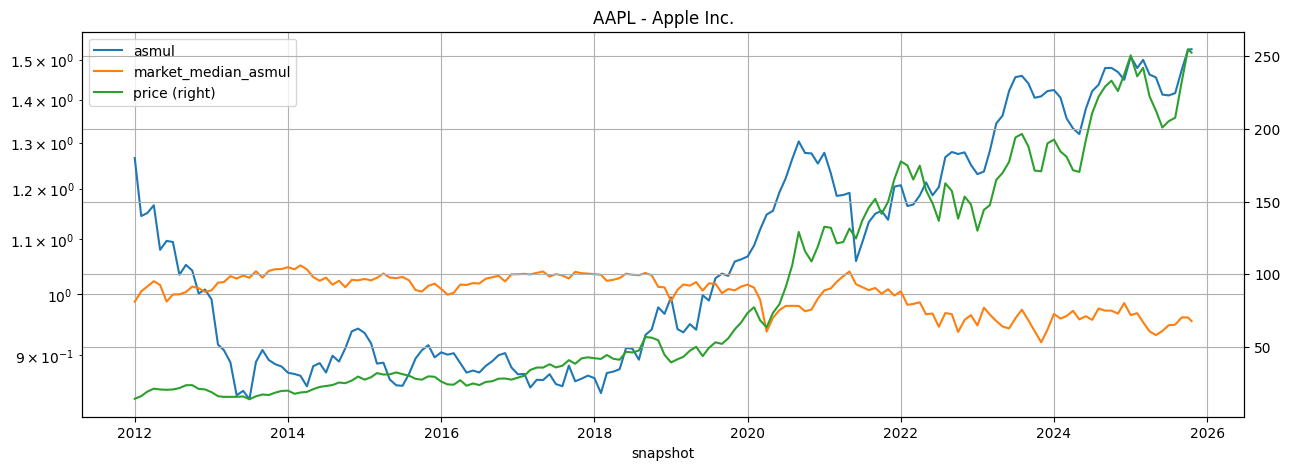

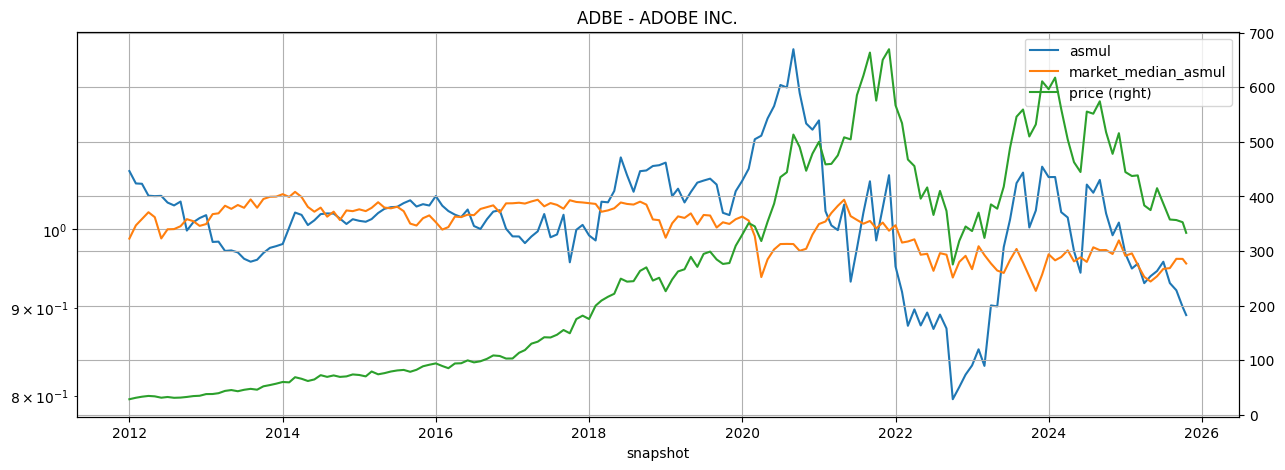

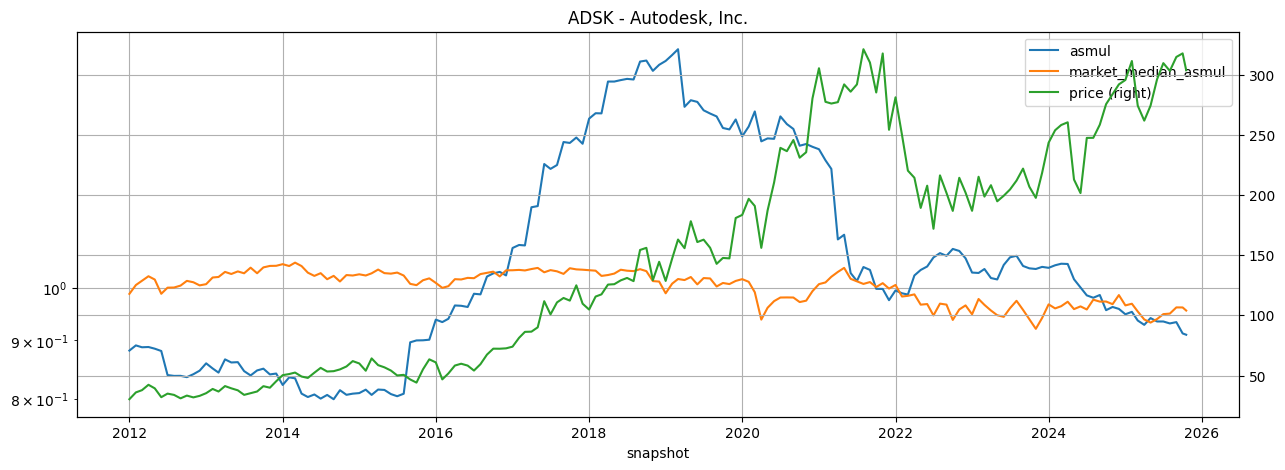

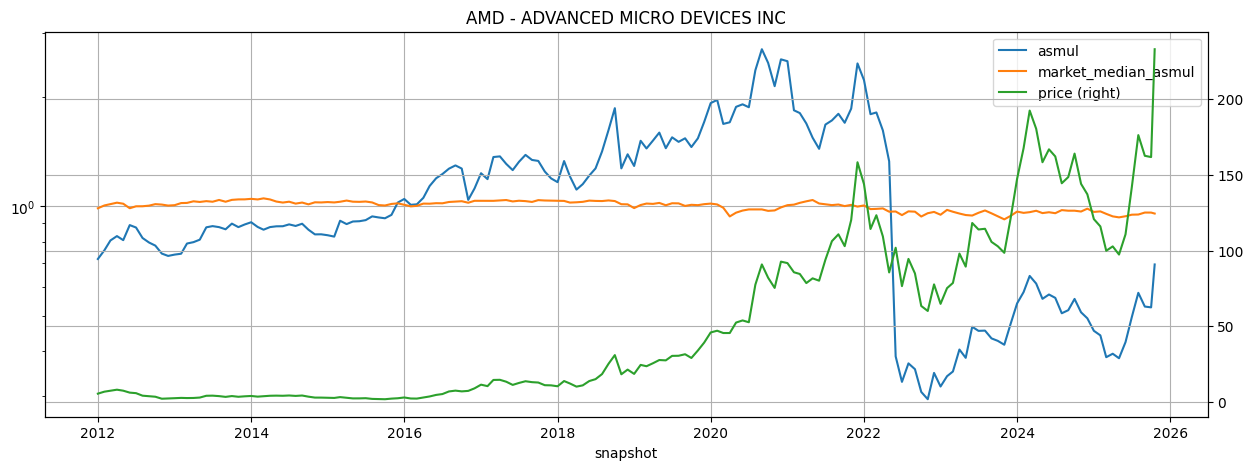

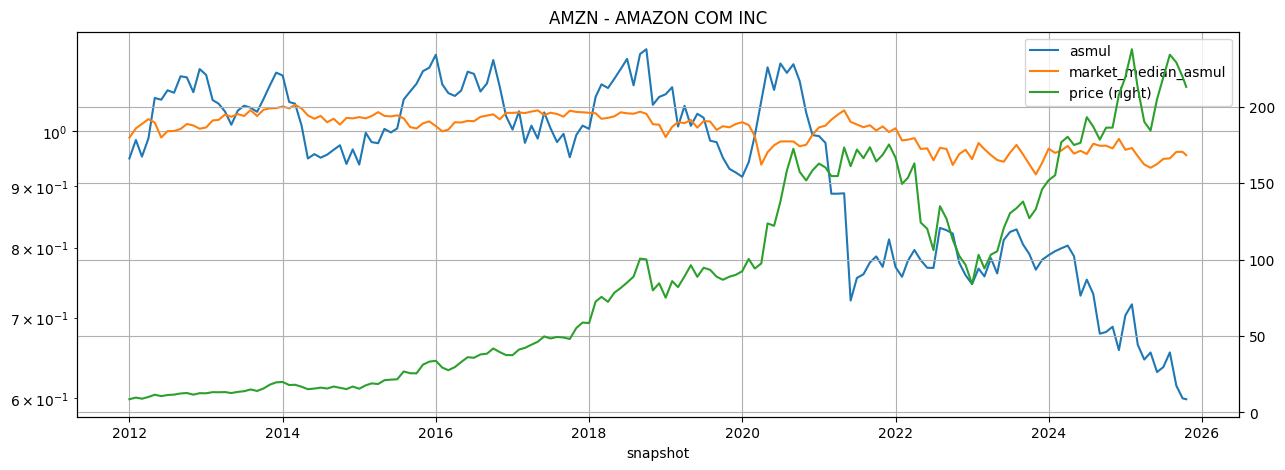

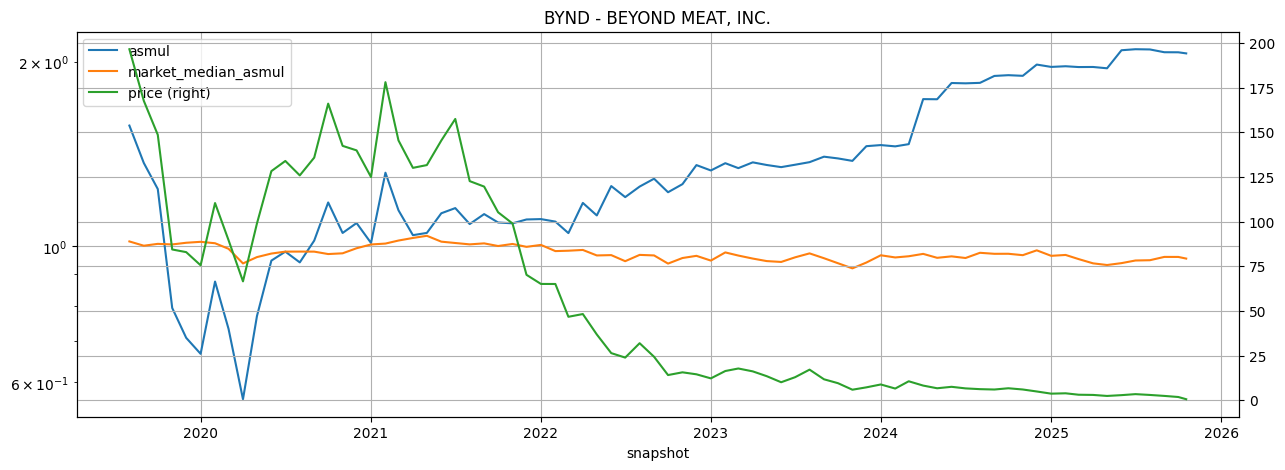

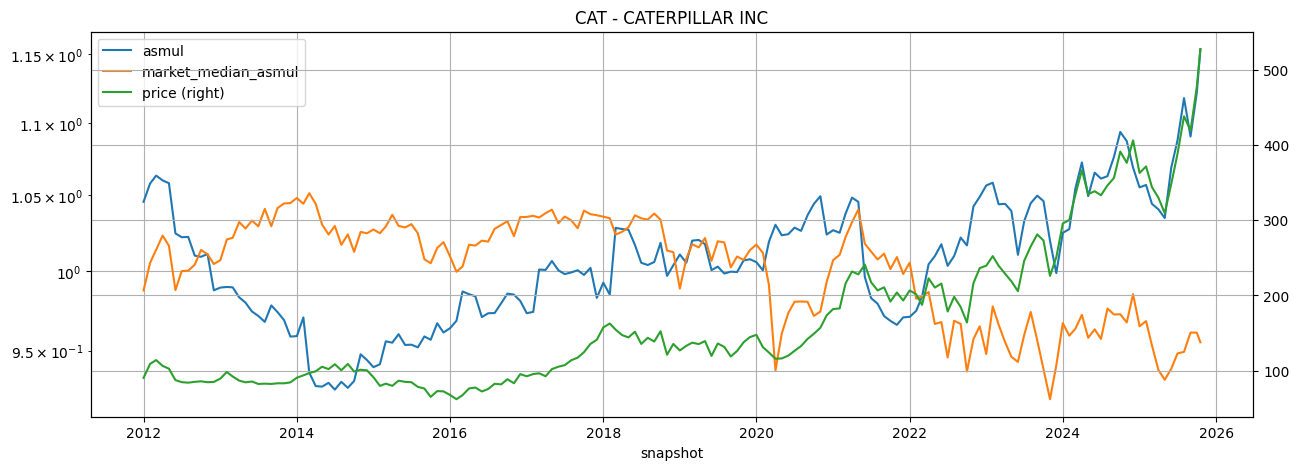

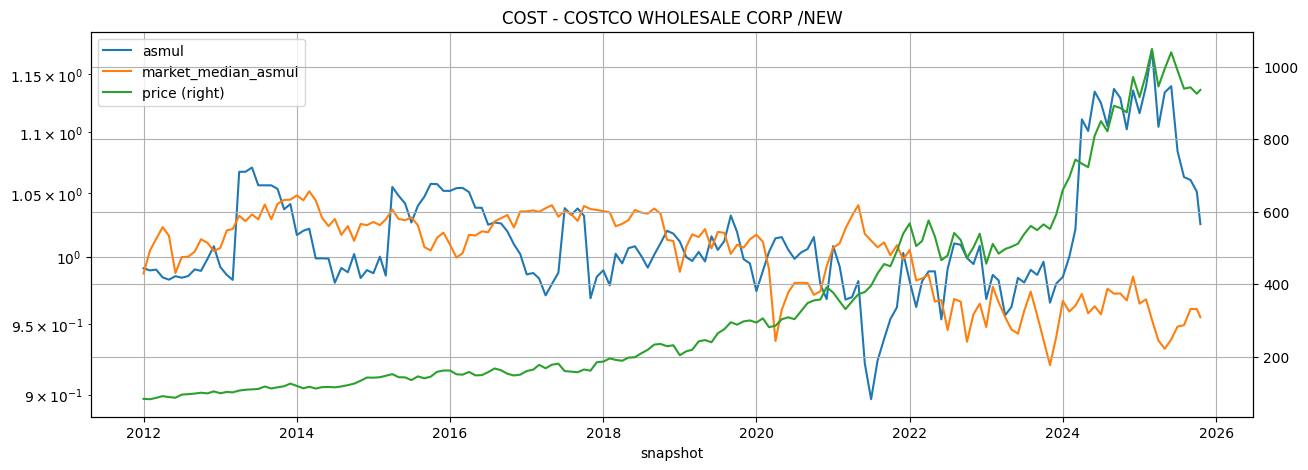

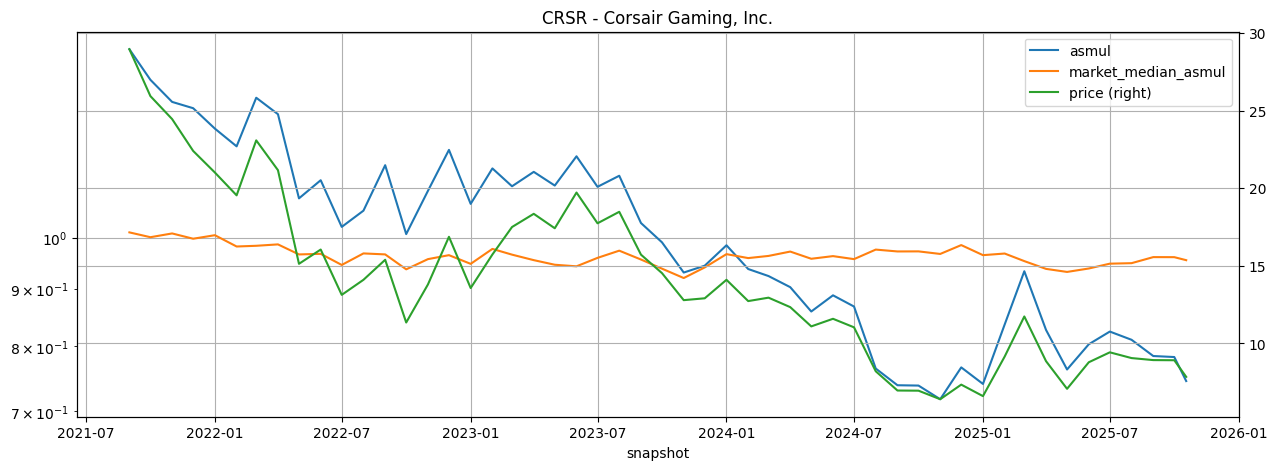

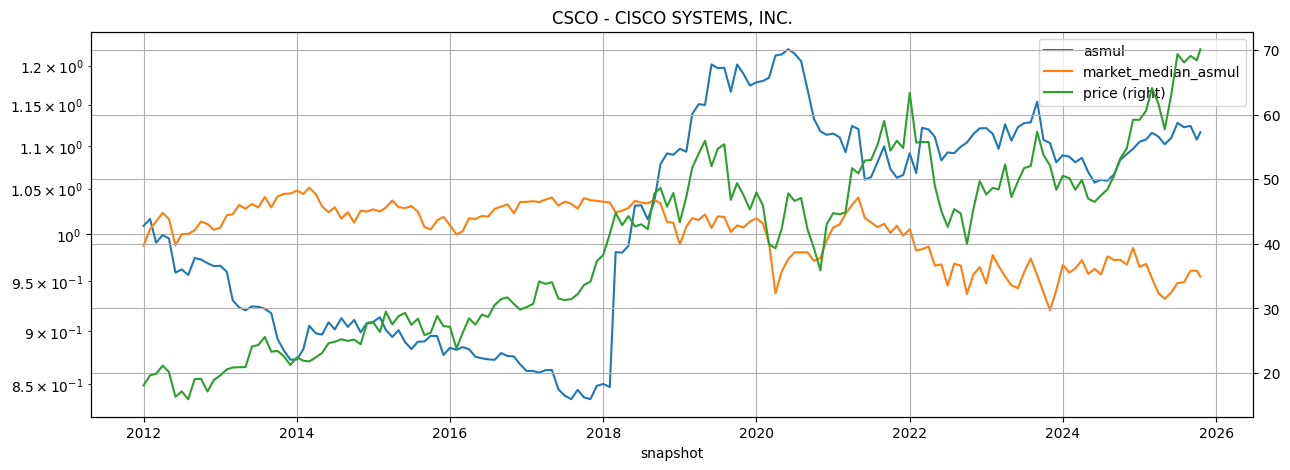

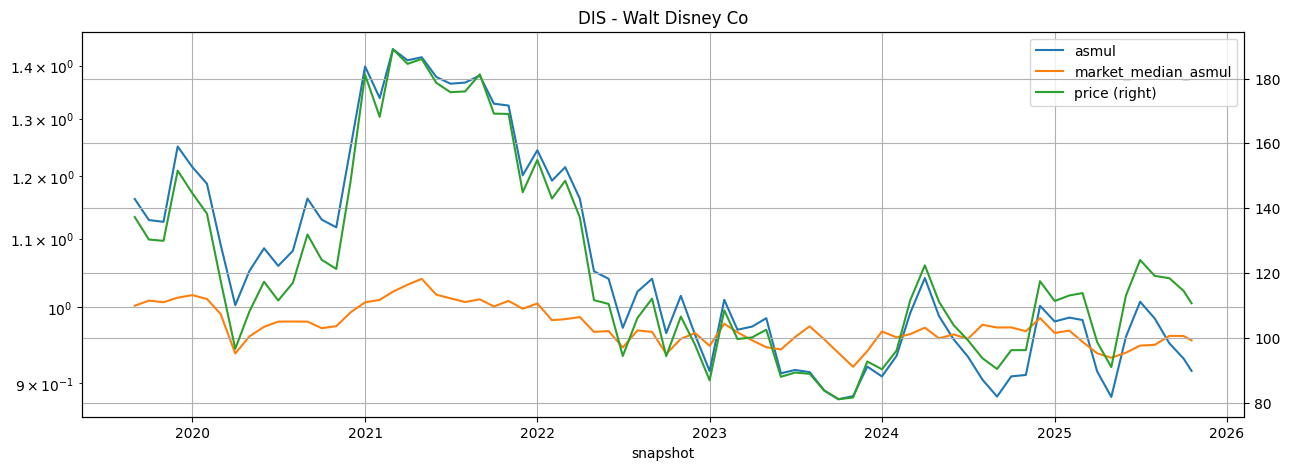

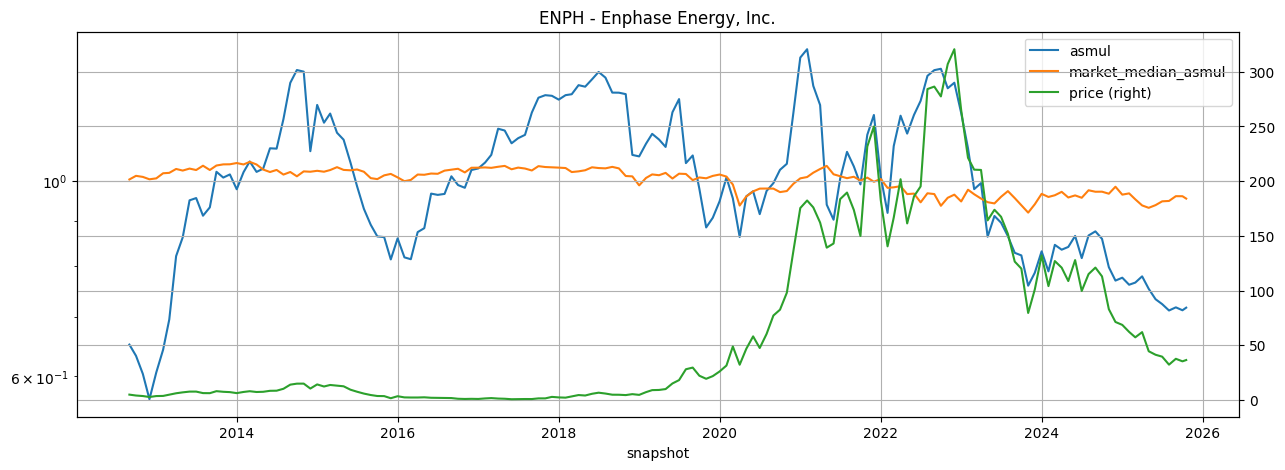

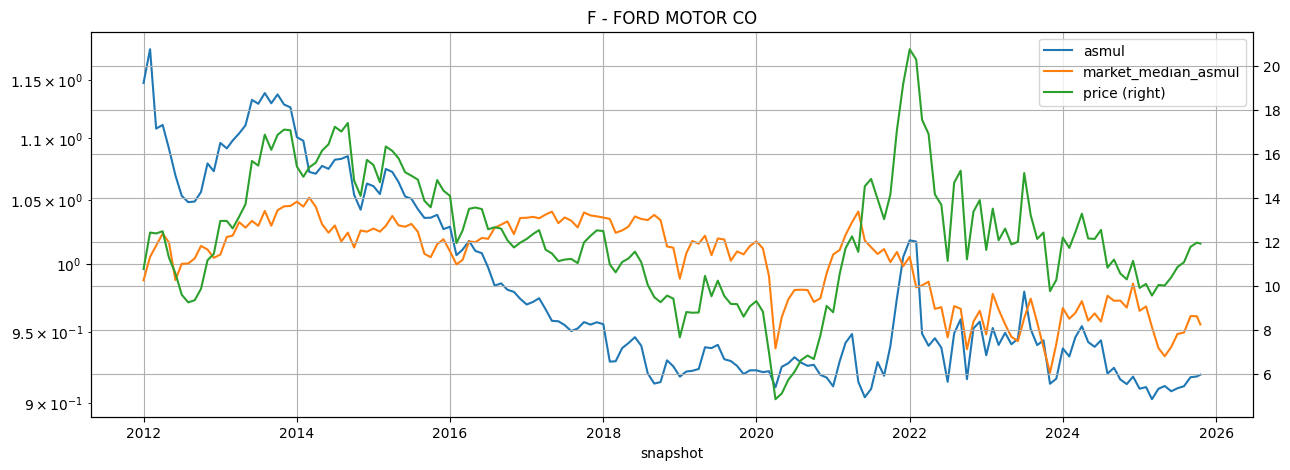

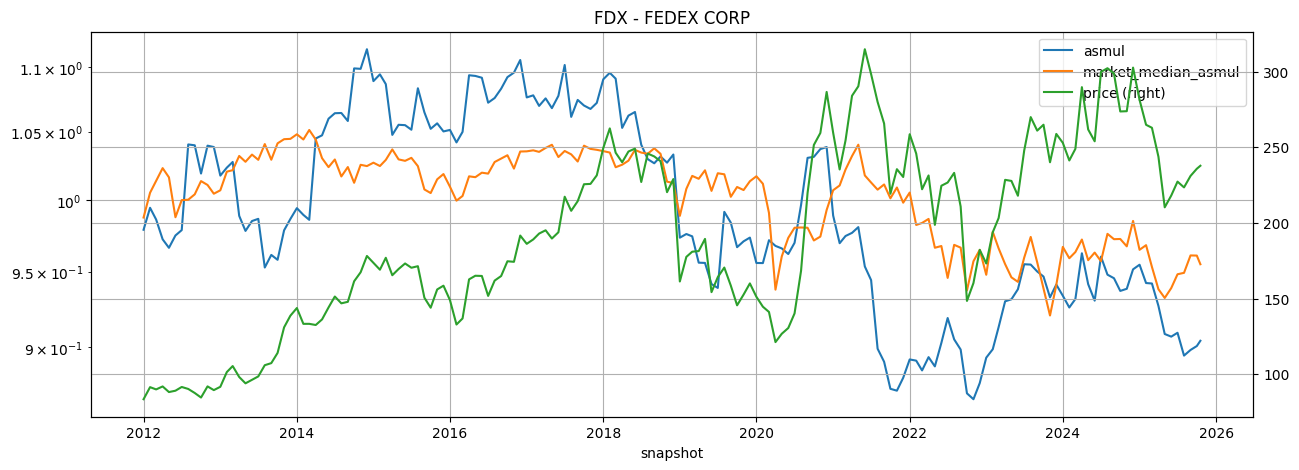

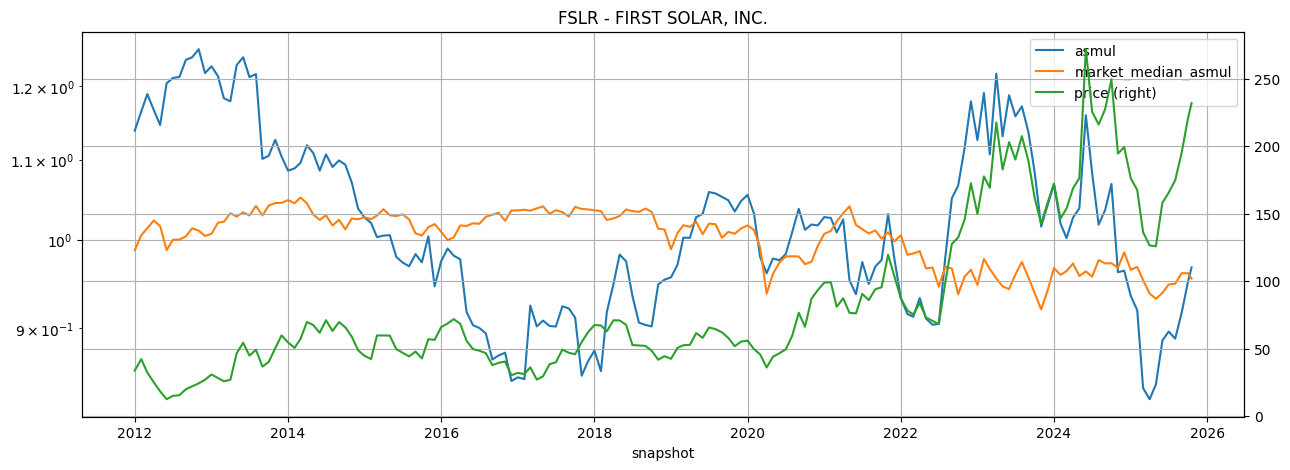

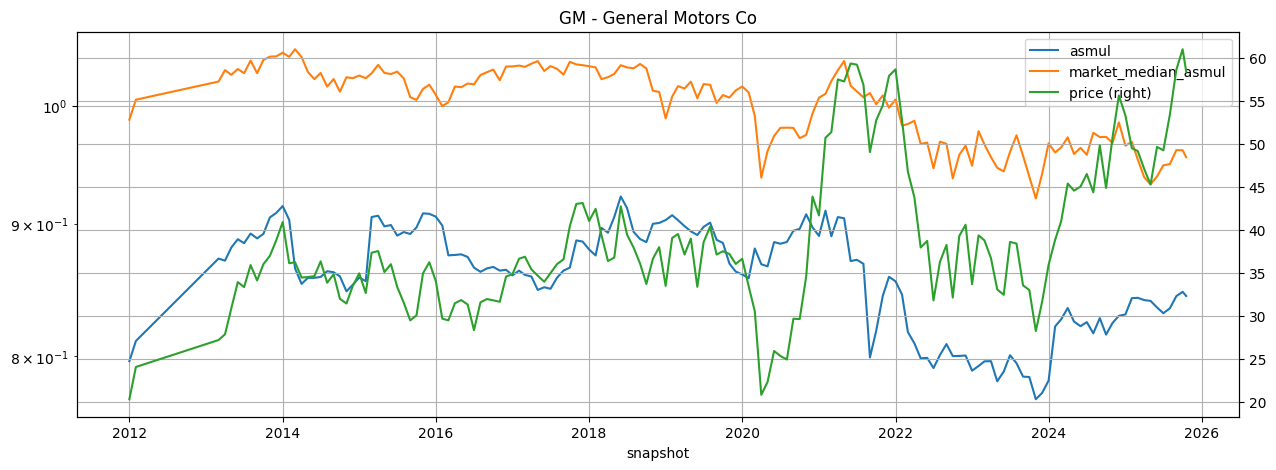

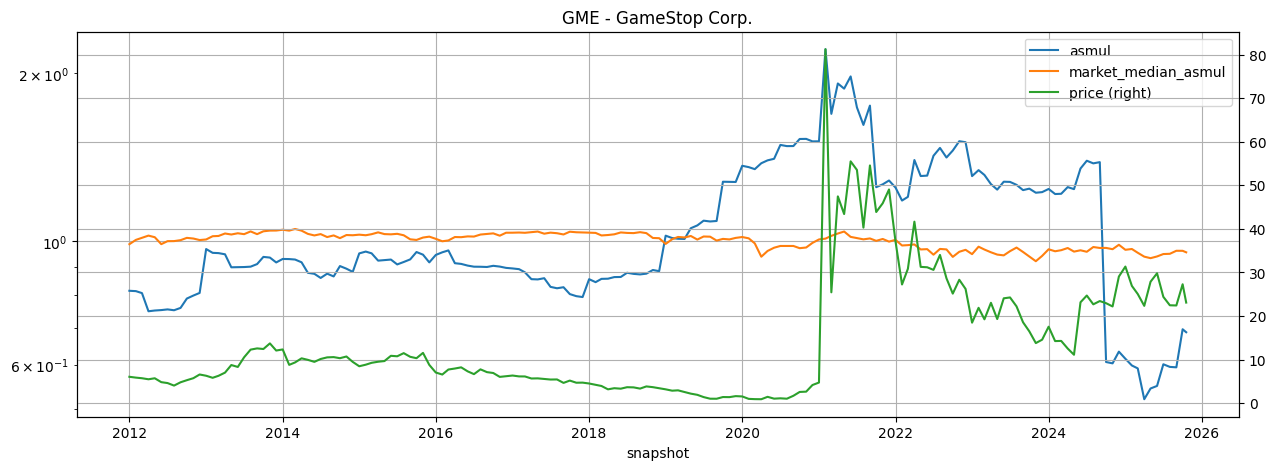

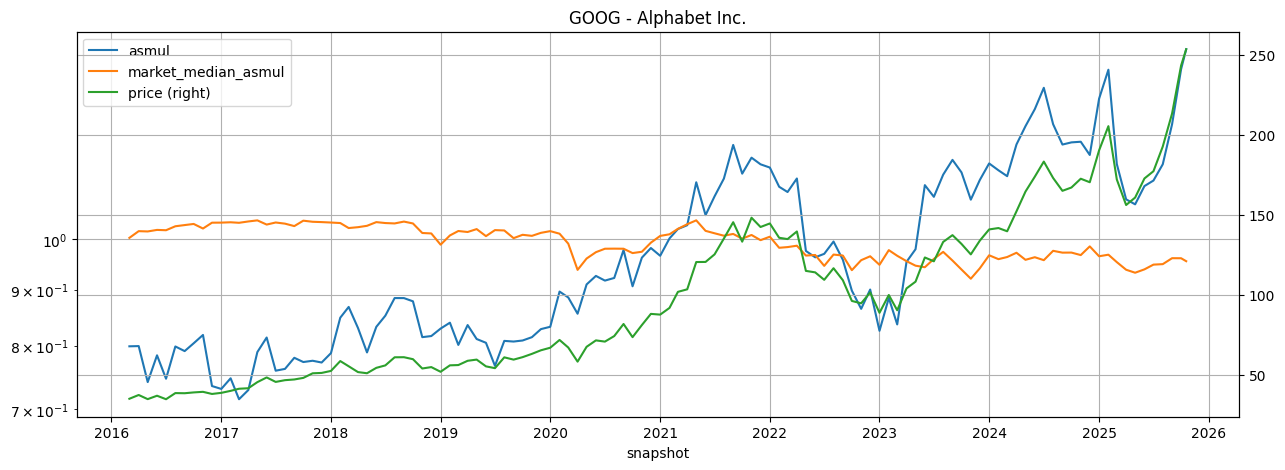

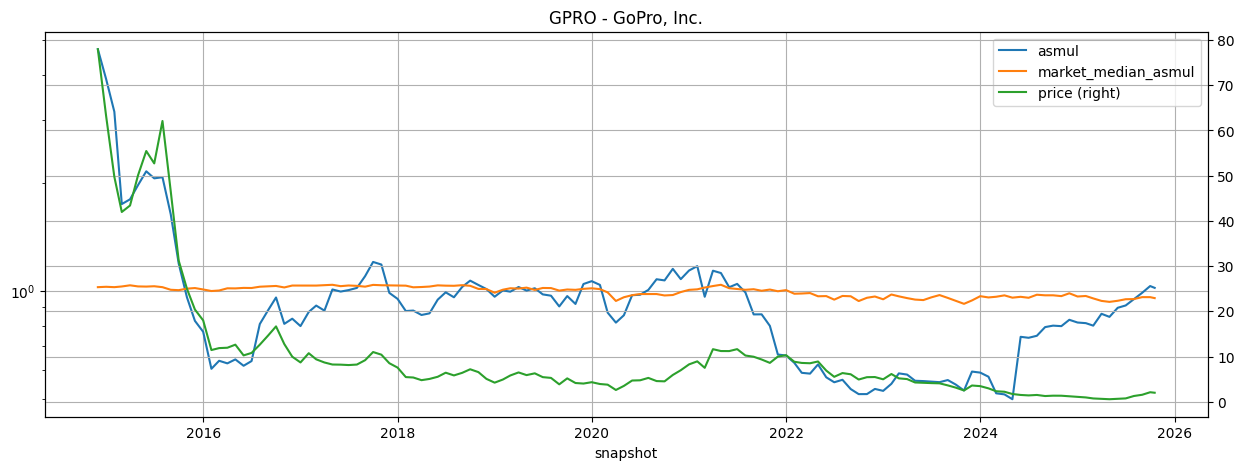

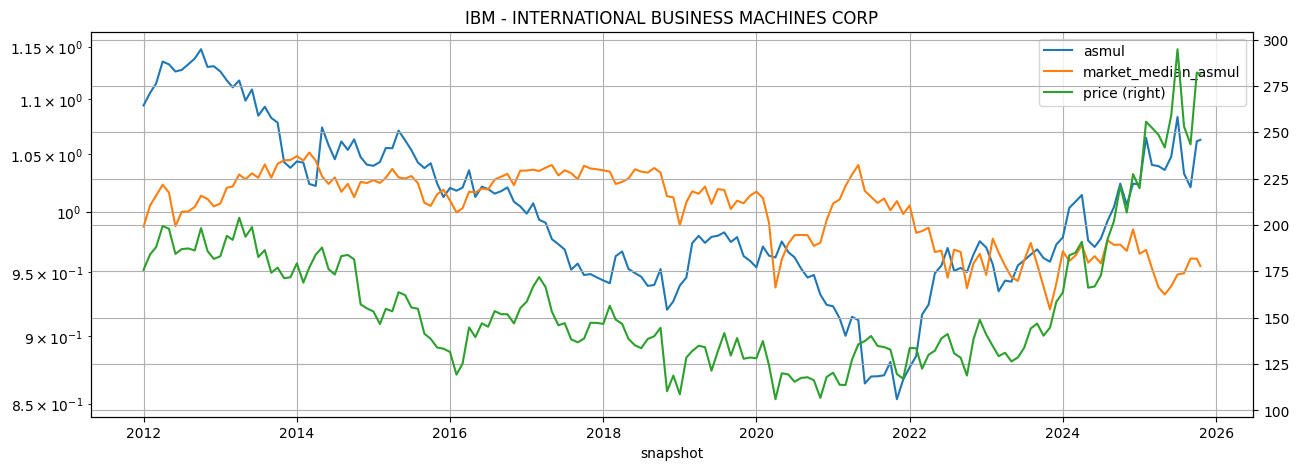

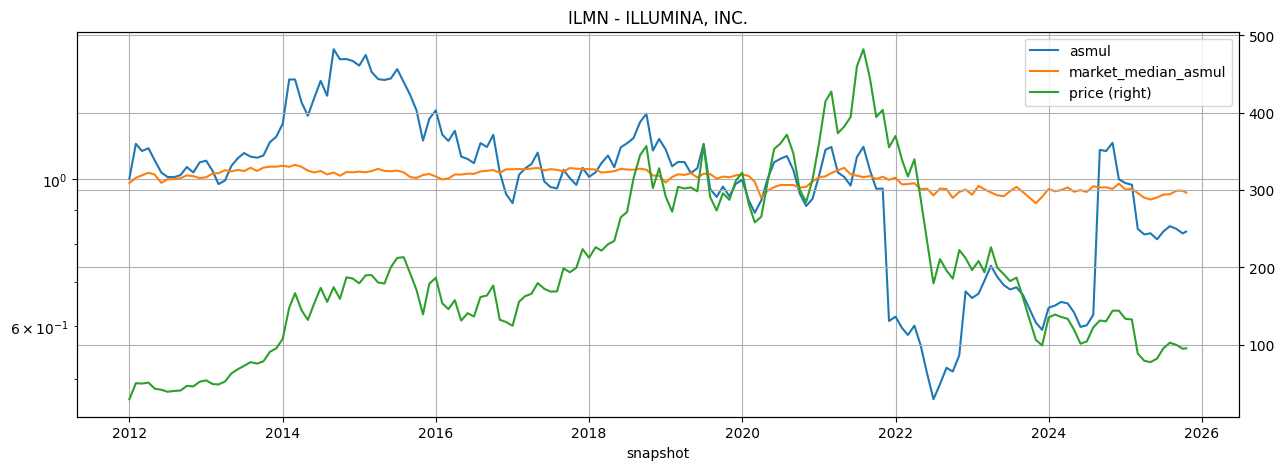

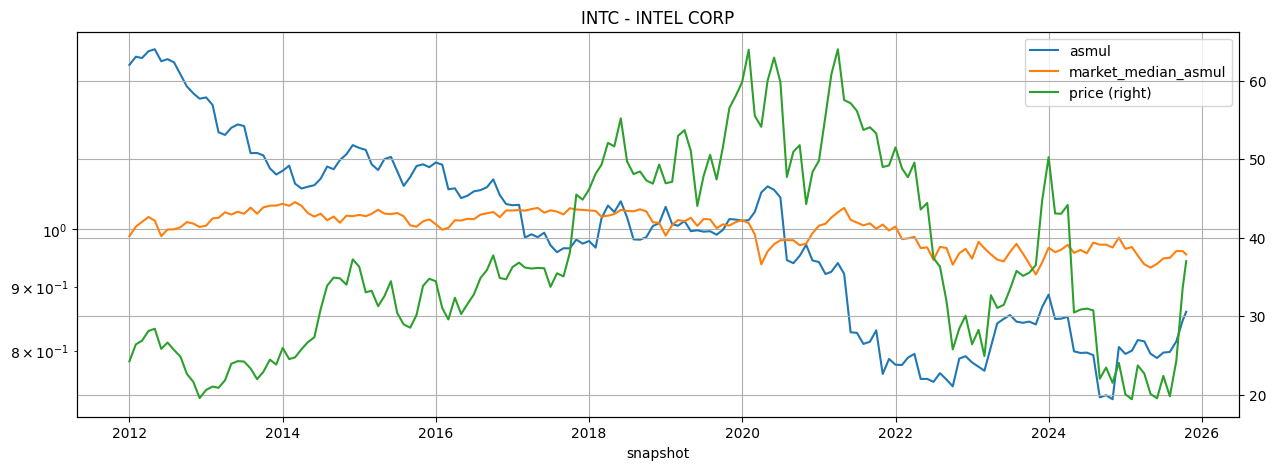

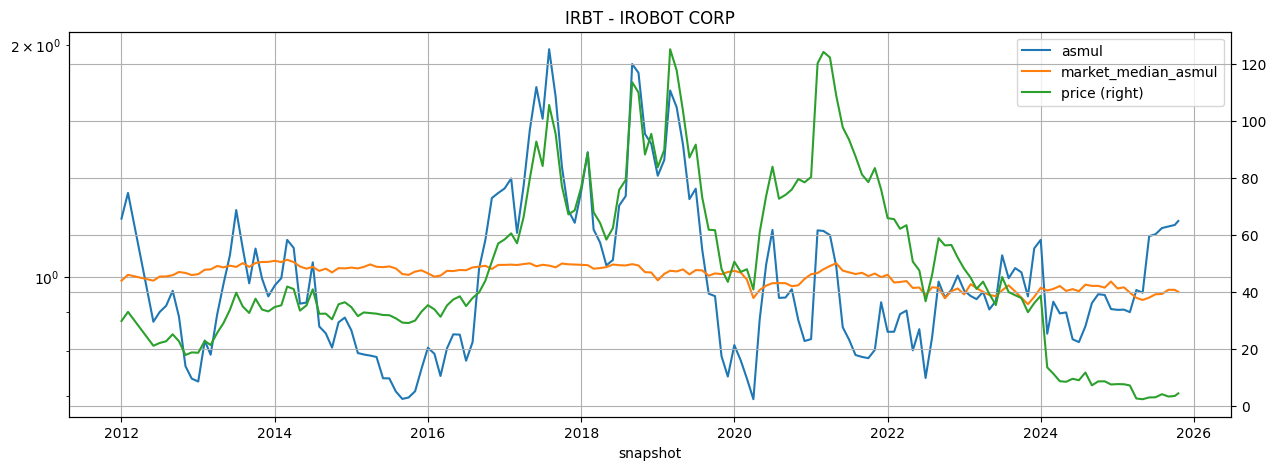

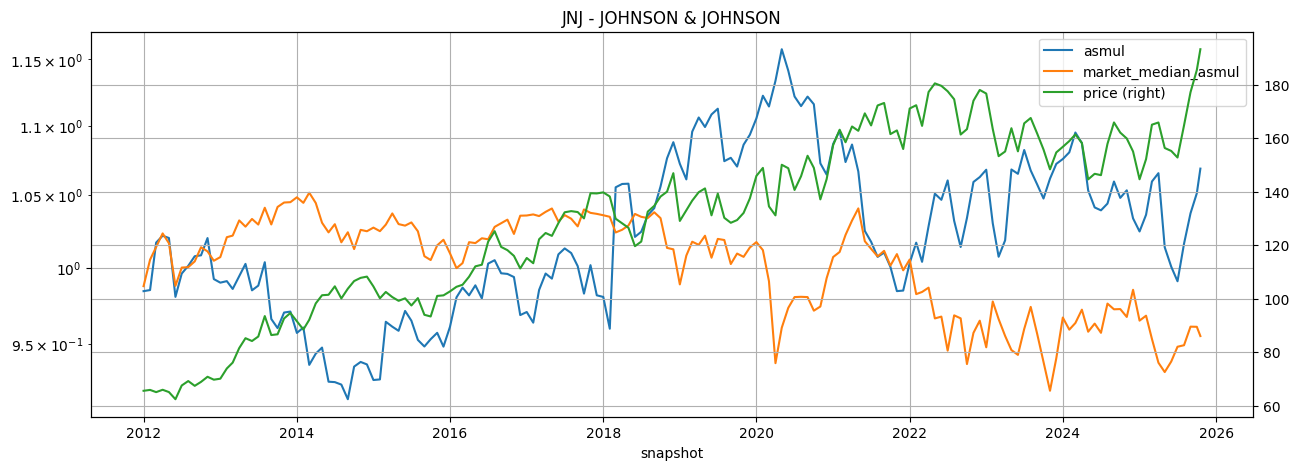

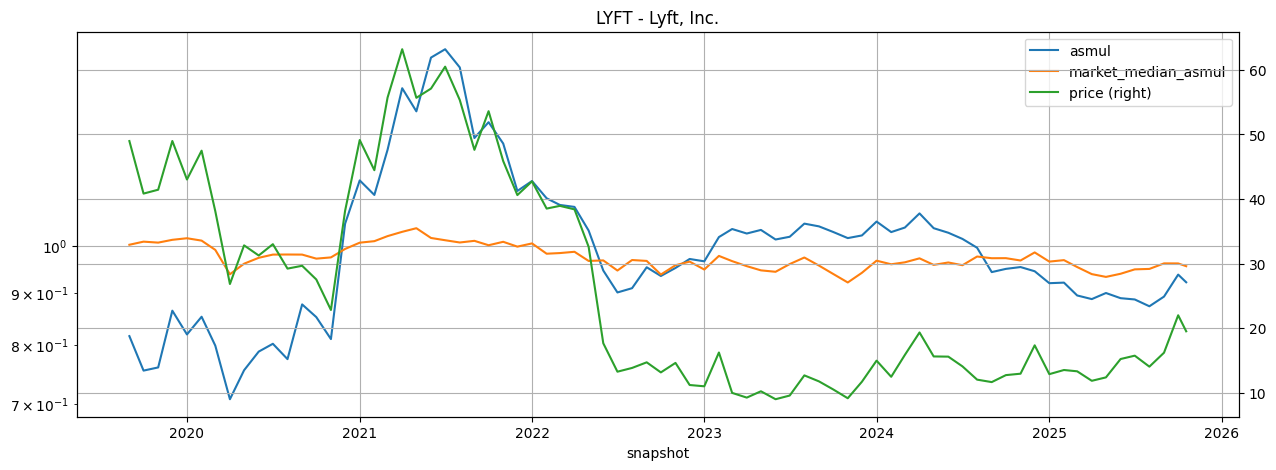

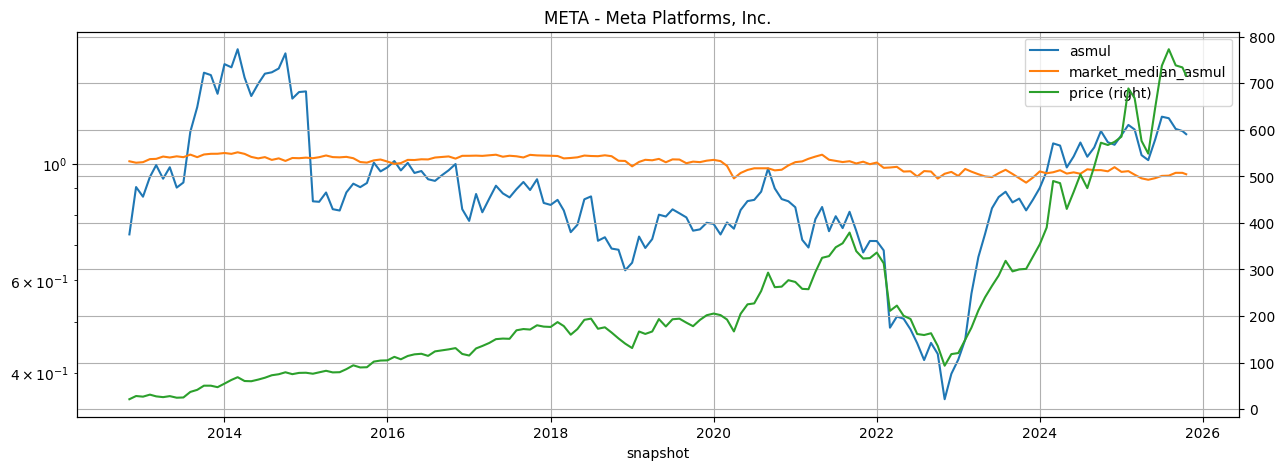

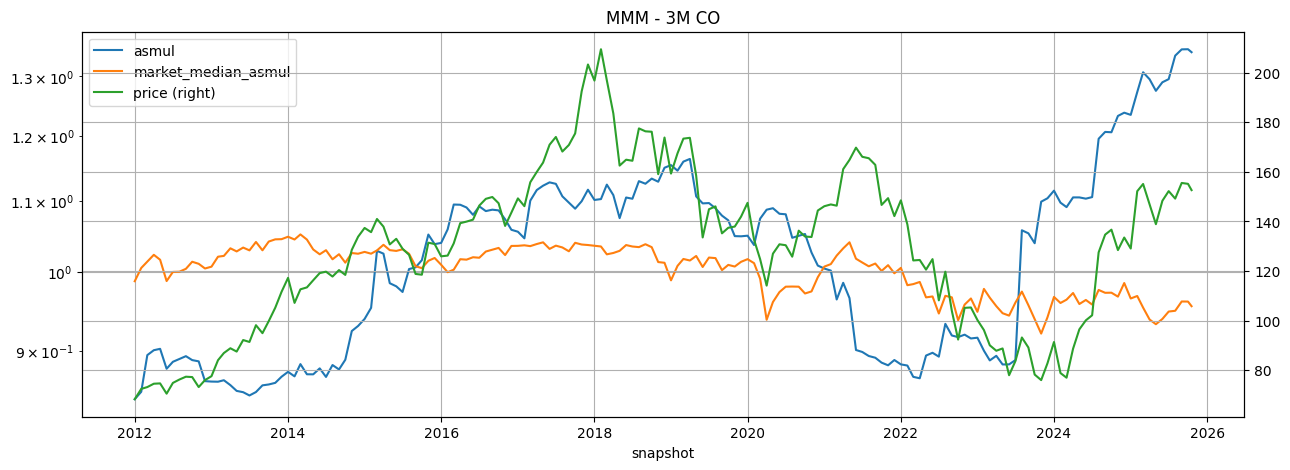

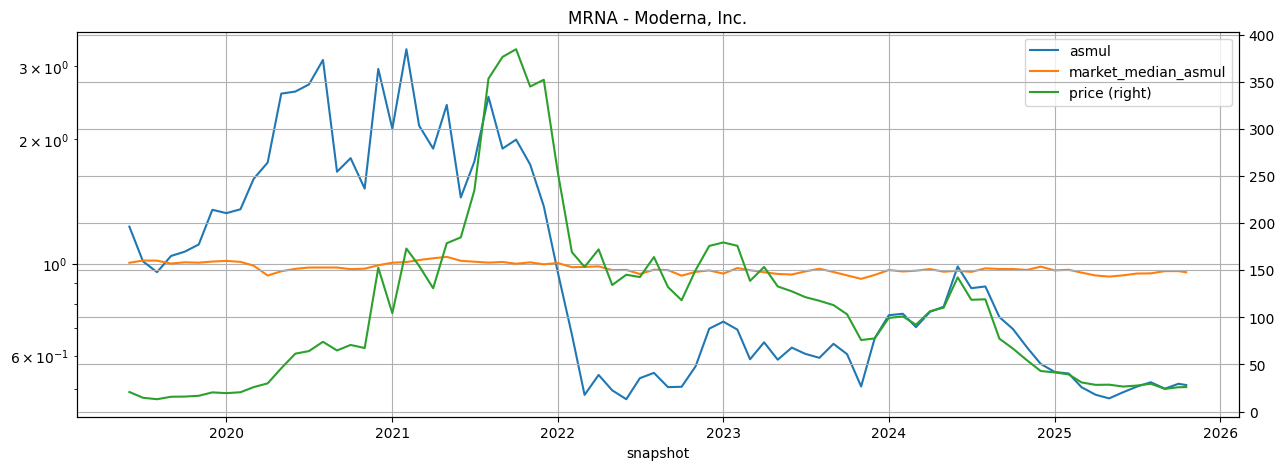

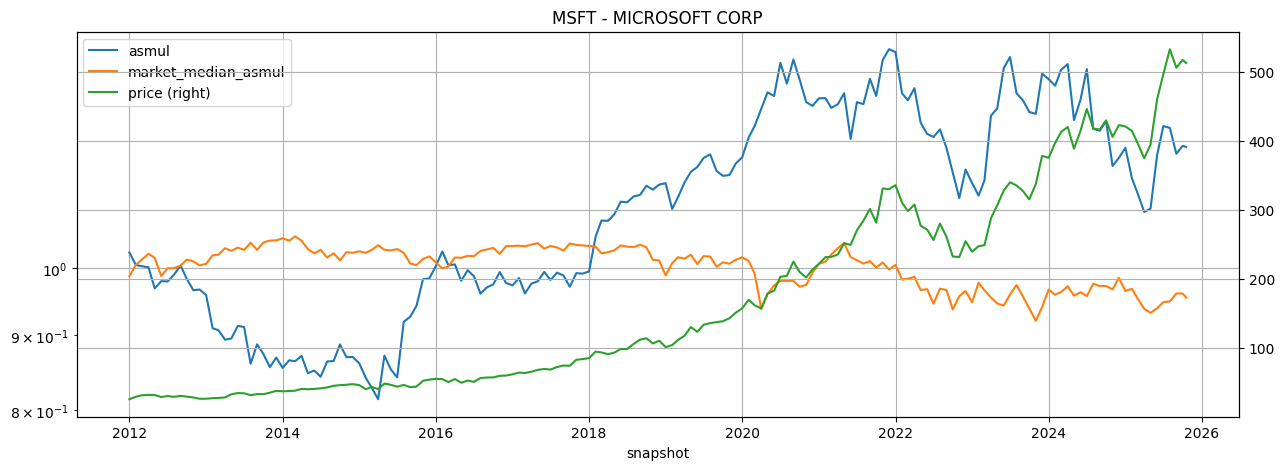

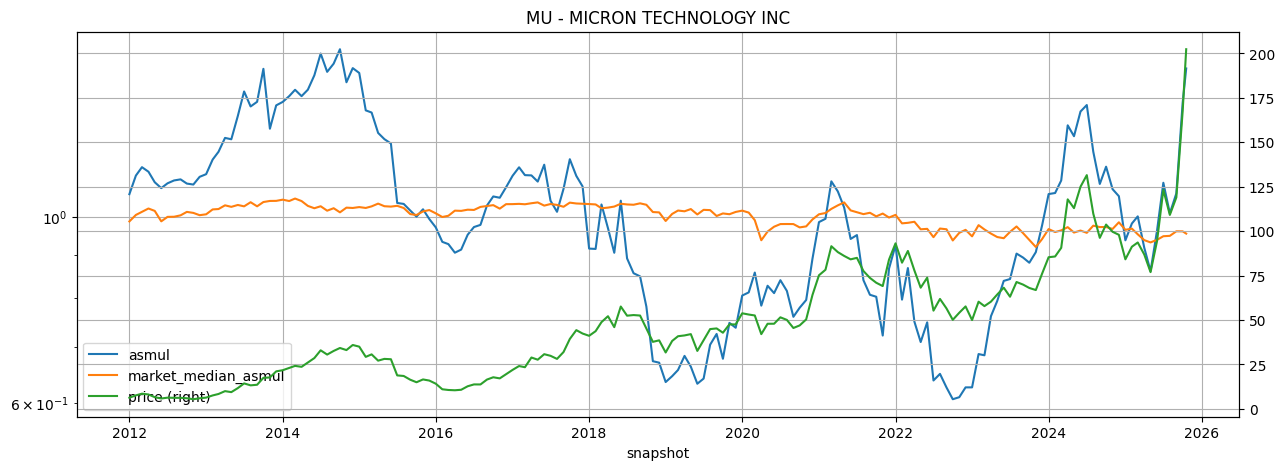

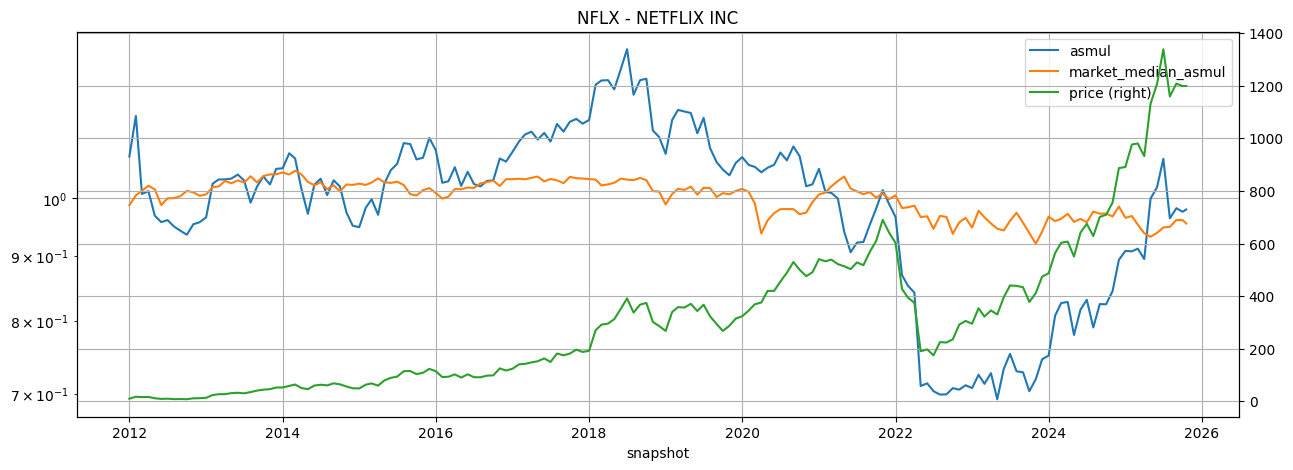

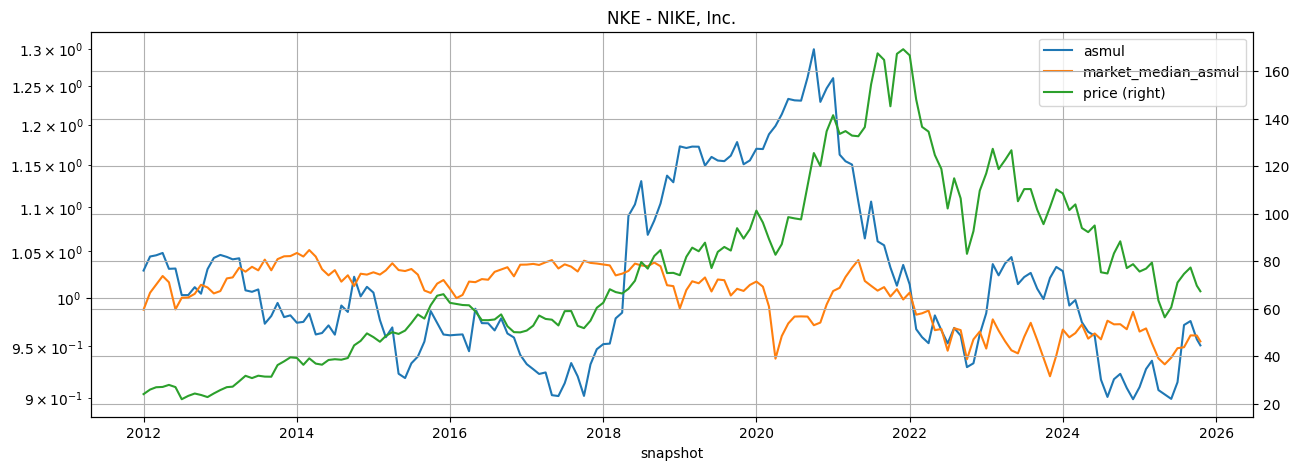

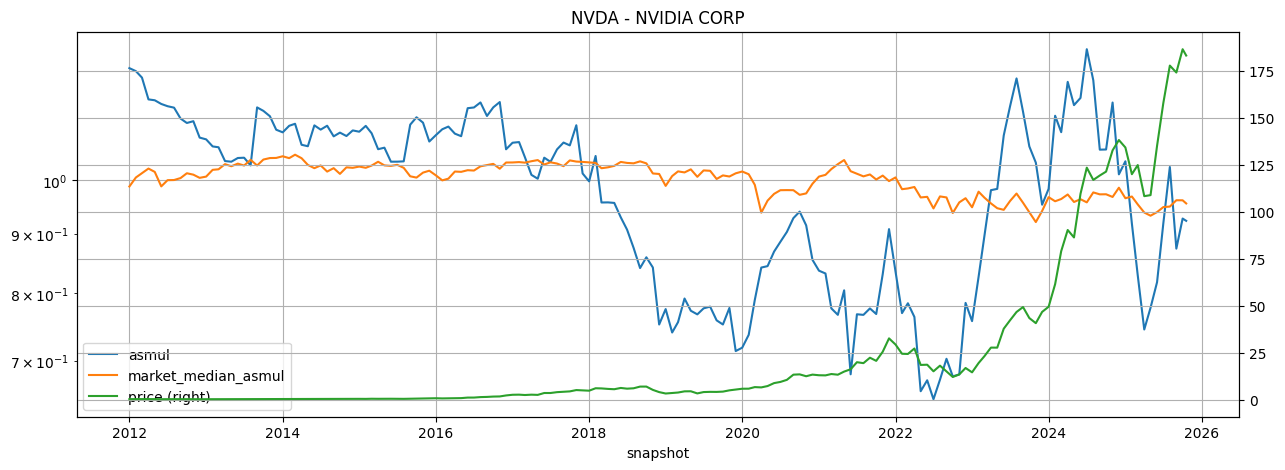

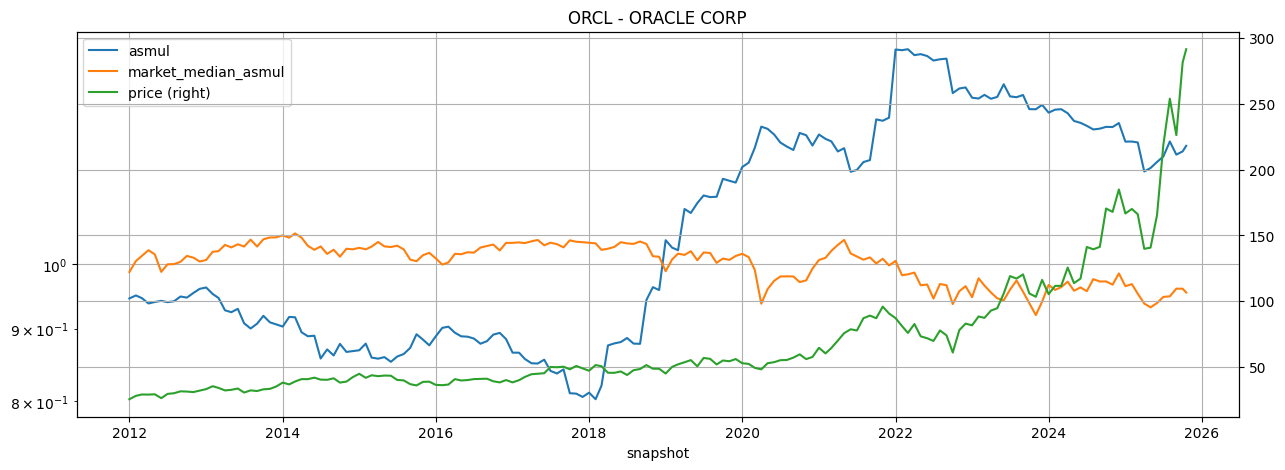

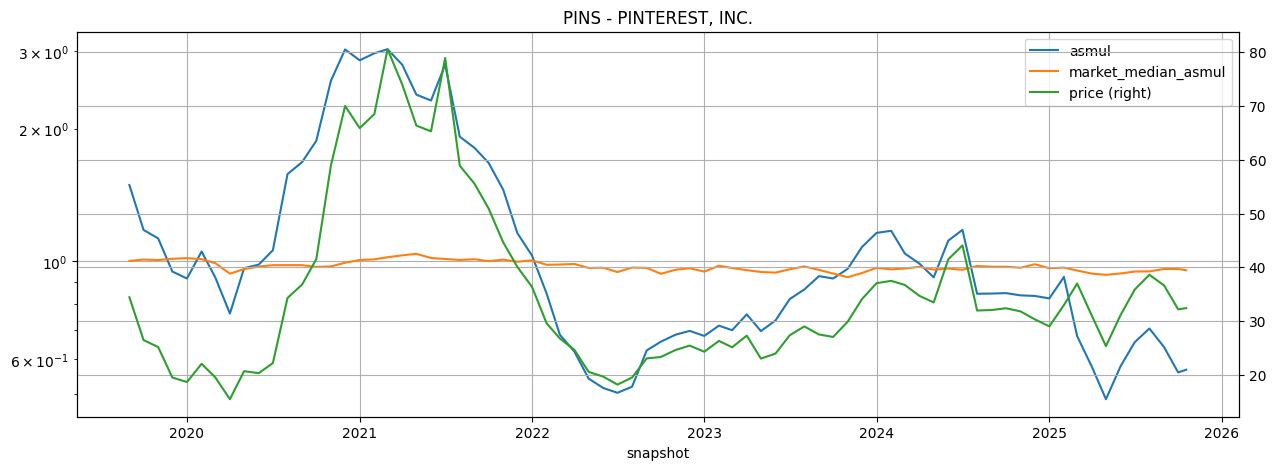

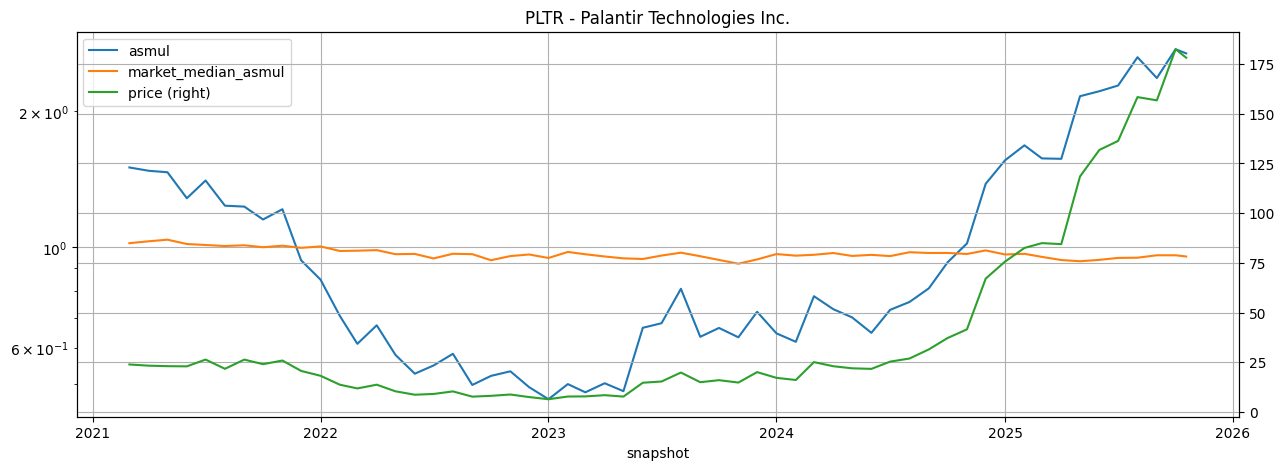

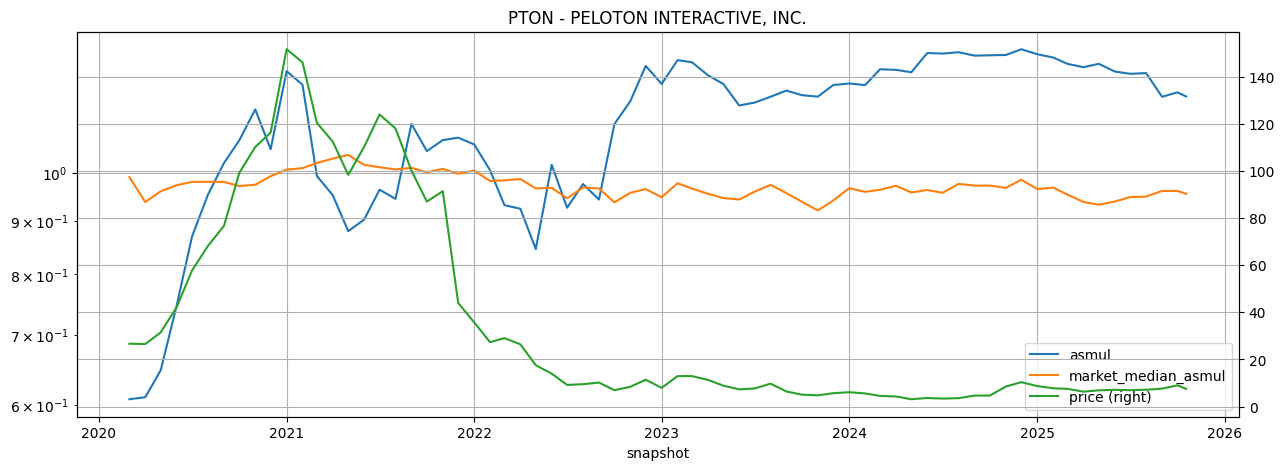

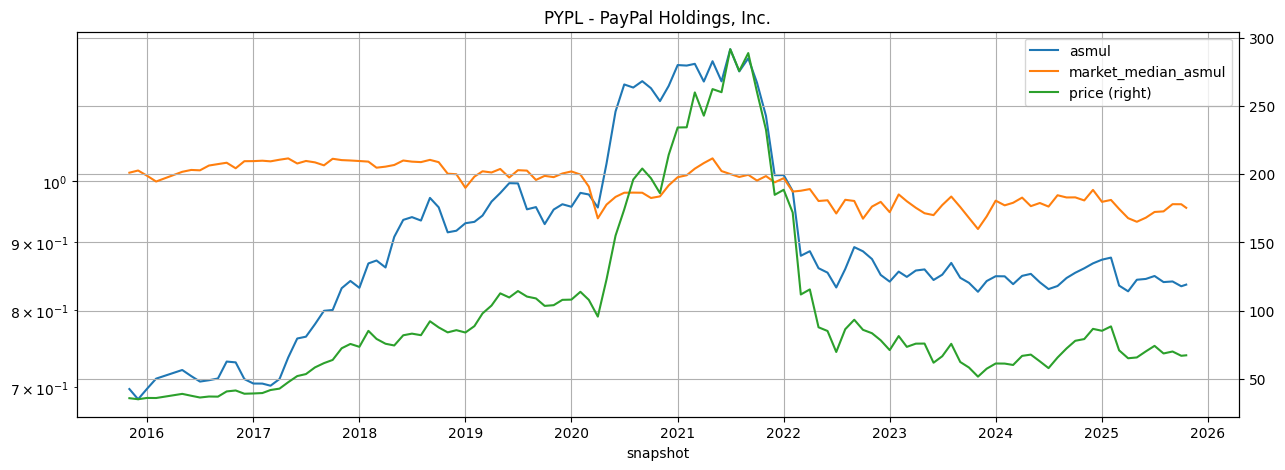

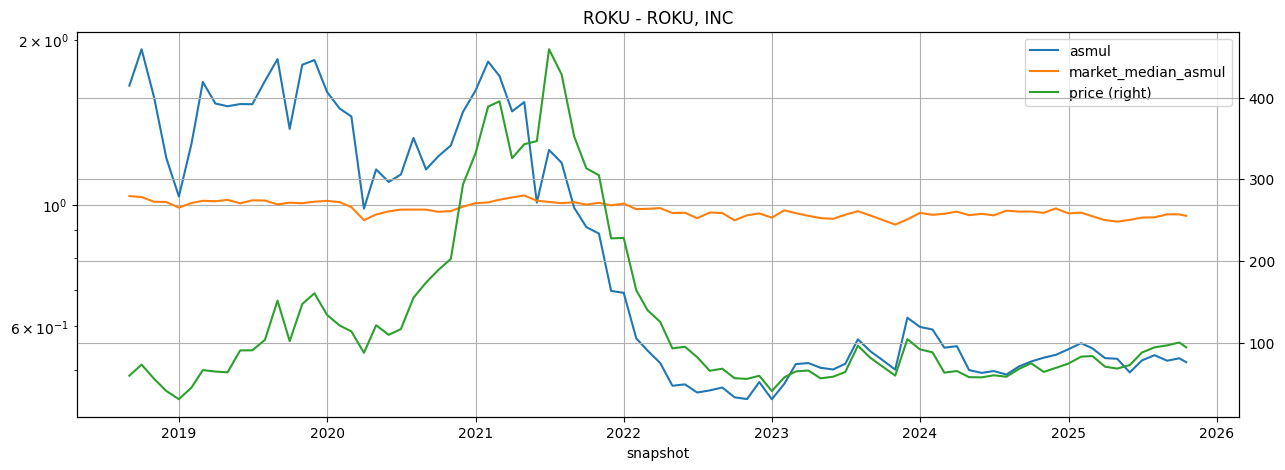

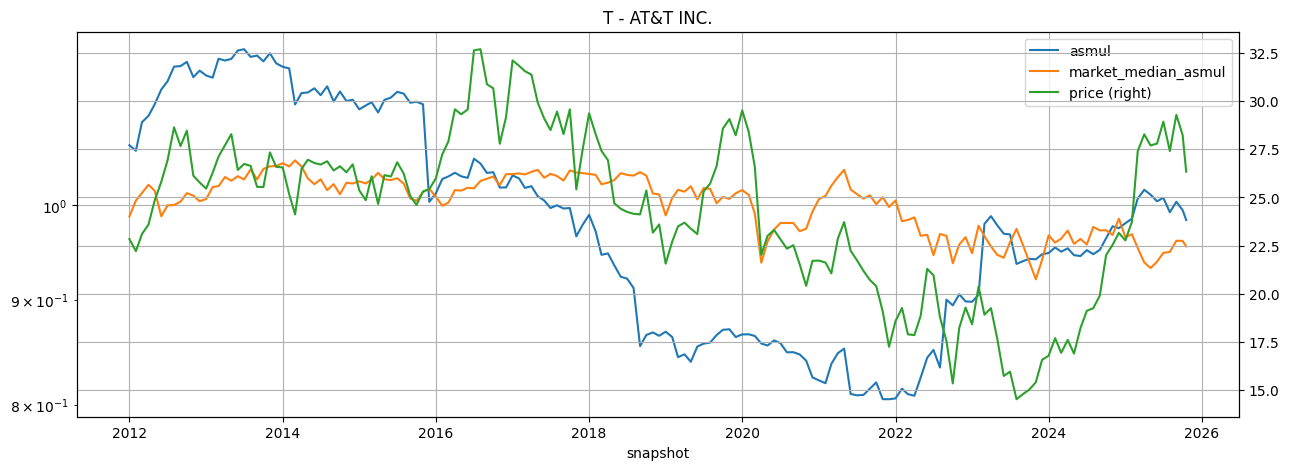

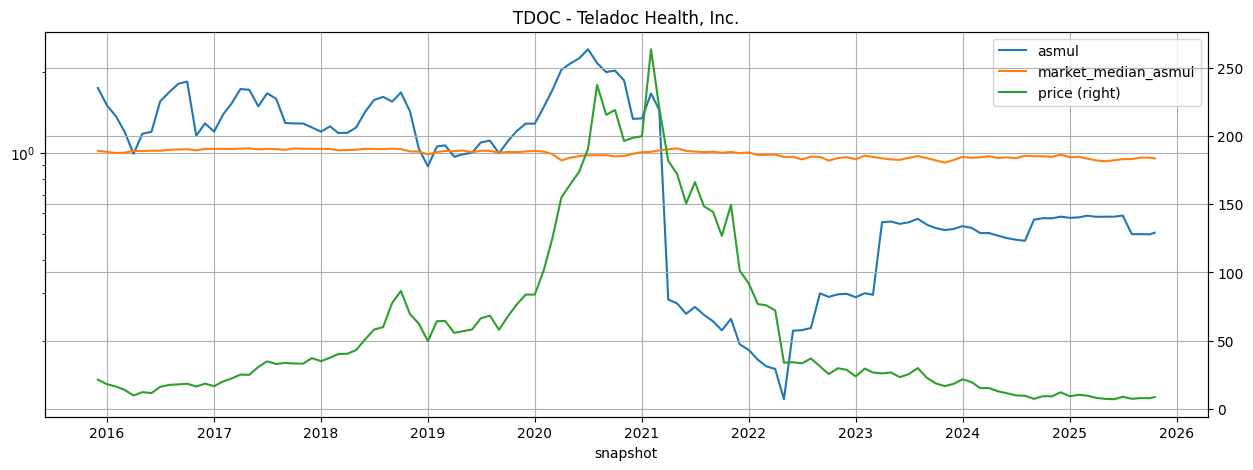

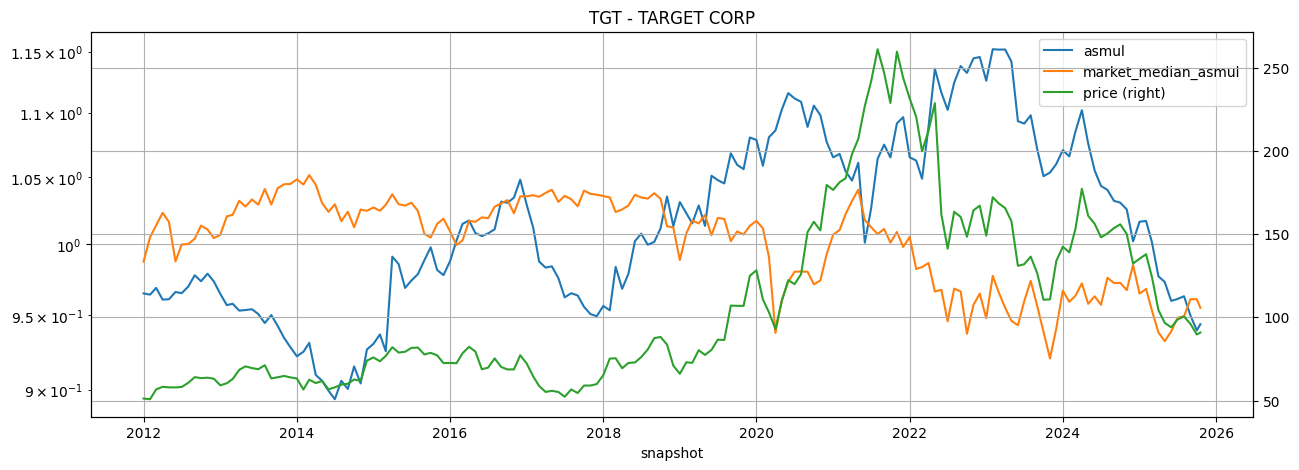

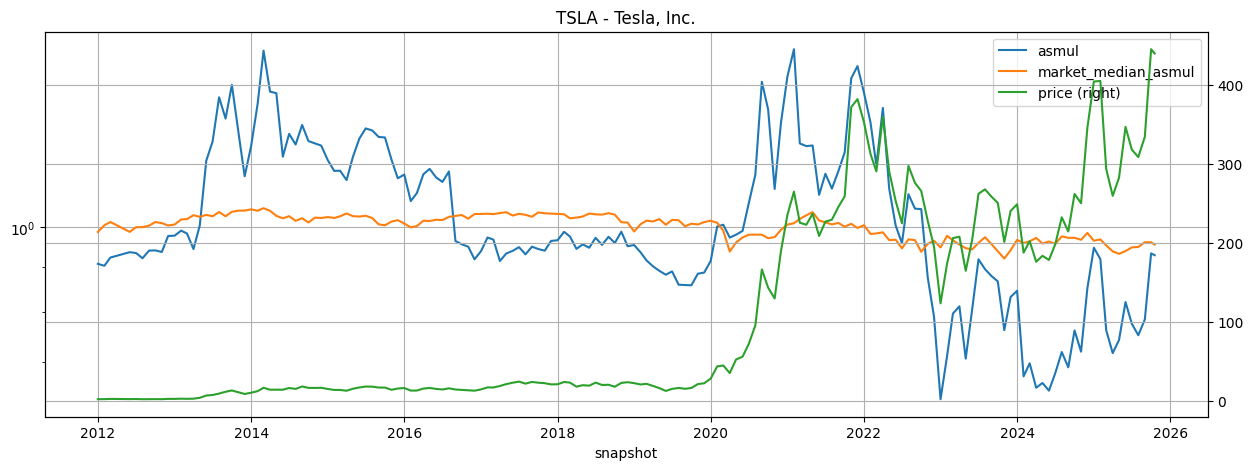

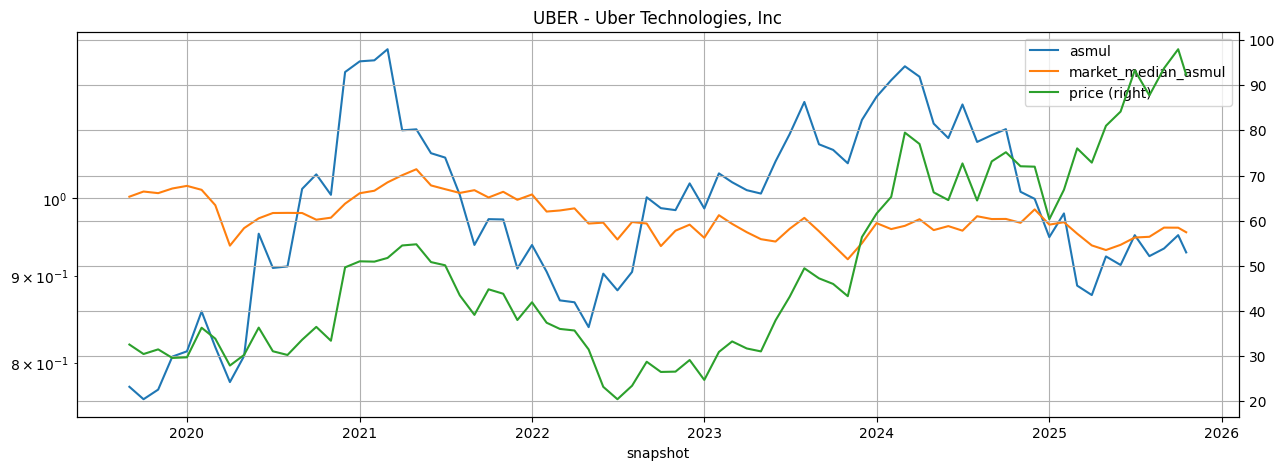

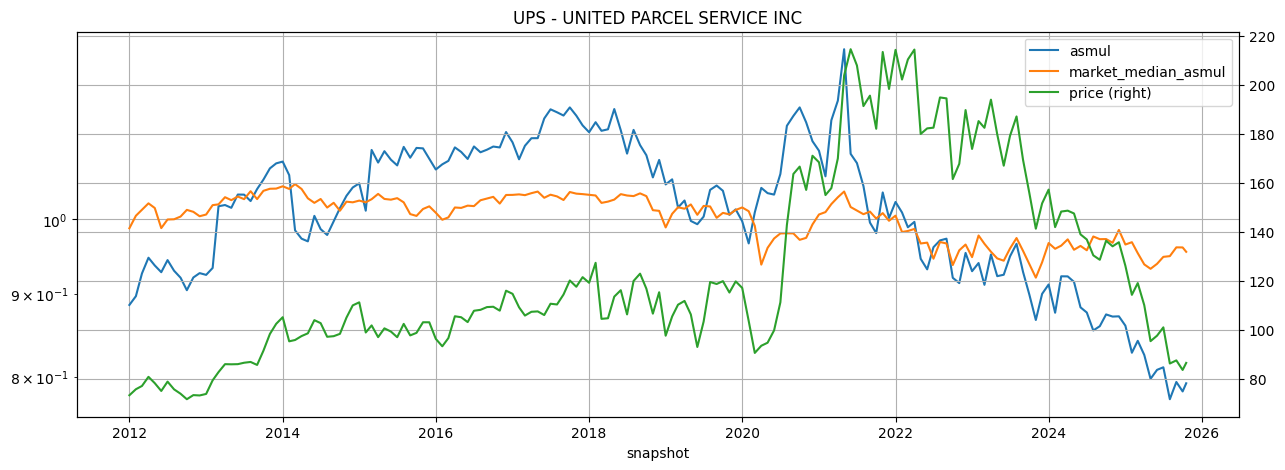

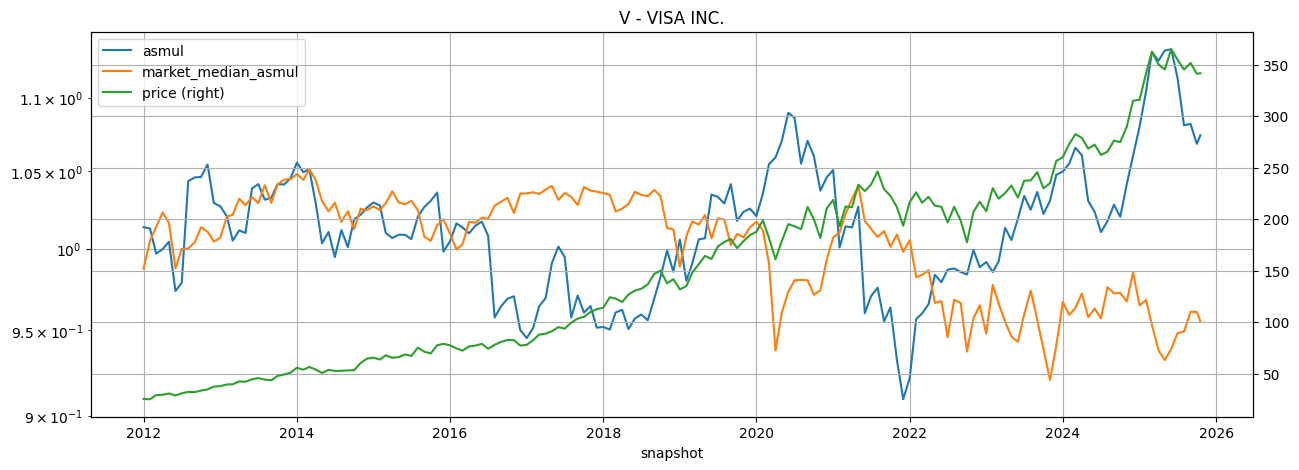

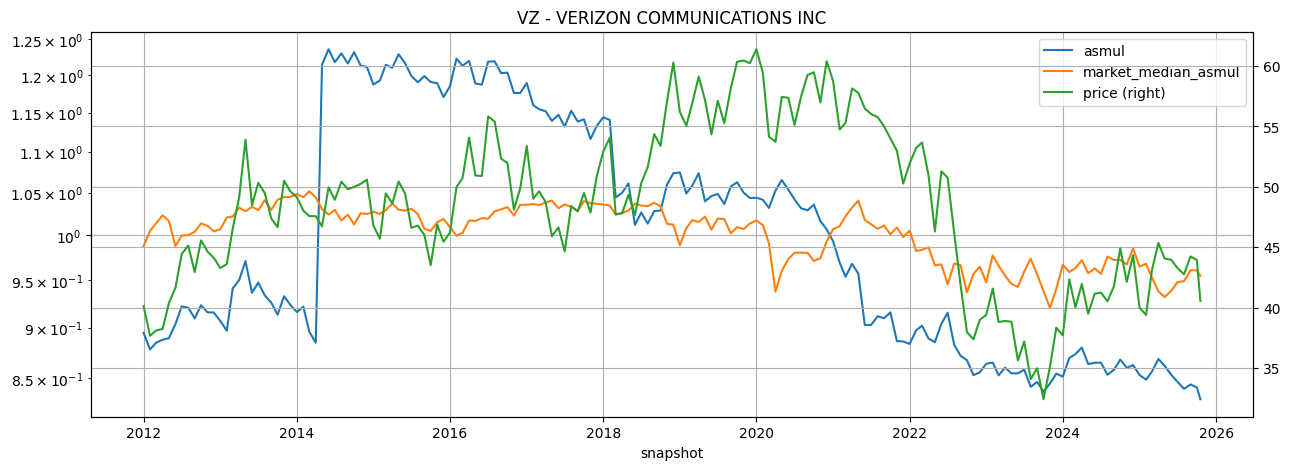

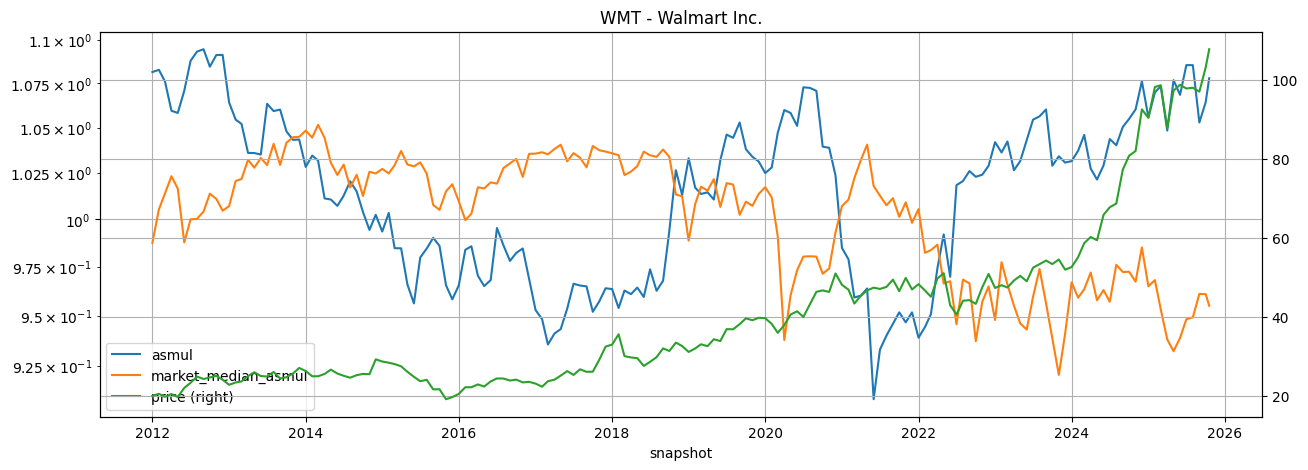

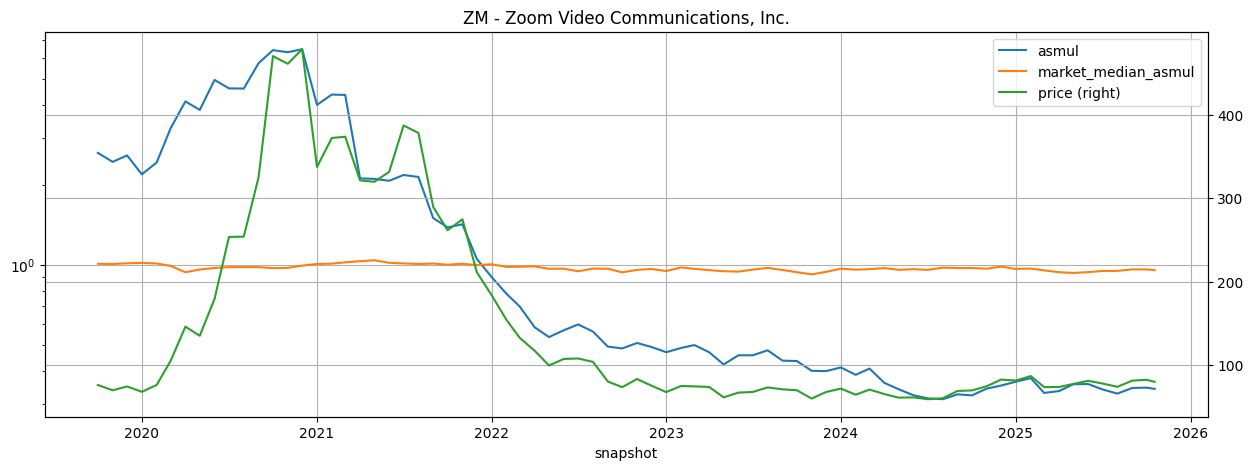

ticker     Assets  Liabilities  \
snapshot   cik        date                                        
2025-10-18 0000320193 2025-06-28   AAPL 331.495000   265.665000   
           0000796343 2025-08-29   ADBE  28.754000    16.984000   
           0000769397 2025-07-31   ADSK  10.856000     8.141000   
           0000002488 2025-06-28    AMD  74.820000    15.155000   
           0001018724 2025-06-30   AMZN 682.170000   348.395000   
           0001655210 2025-06-28   BYND   0.691741     1.368764   
           0000018230 2025-06-30    CAT  90.325000    71.662000   
           0000909832 2025-08-31   COST  77.099000    47.935000   
           0001743759 2025-06-30   CRSR   1.221880     0.617983   
           0000858877 2025-07-26   CSCO 122.291000    75.448000   
           0001744489 2025-06-28    DIS 196.612000    87.467000   
           0001463101 2025-06-30   ENPH   3.178789     2.298152   
           0000037996 2025-06-30      F 292.725000   247.668000   
           0001048911 2025-08-31    FDX  88.416000    60.645000   
           0001274494 2025-06-30   FSLR  12.858044     4.311914   
           0001467858 2025-06-30     GM 289.384000   223.021000   
           0001326380 2025-08-02    GME  10.341100     5.164700   
           0001652044 2025-06-30   GOOG 502.053000   139.137000   
           0001500435 2025-06-30   GPRO   0.438990     0.341075   
           0000051143 2025-06-30    IBM 148.585000   121.076000   
           0001110803 2025-06-29   ILMN   6.087000     3.829000   
           0000050863 2025-06-28   INTC 192.520000    94.637000   
           0001159167 2025-06-28   IRBT   0.480320     0.488012   
           0000200406 2025-06-29    JNJ 193.389000   114.916000   
           0001759509 2025-06-30   LYFT   5.369367     4.636691   
           0001326801 2025-06-30   META 294.744000    99.674000   
           0000066740 2025-06-30    MMM  37.989000    33.699000   
           0001682852 2025-06-30   MRNA  12.010000     2.611000   
           0000789019 2025-06-30   MSFT 619.003000   275.524000   
           0000723125 2025-08-28     MU  82.798000    28.633000   
           0001065280 2025-06-30   NFLX  53.099664    28.147765   
           0000320187 2025-08-31    NKE  37.334000    23.866000   
           0001045810 2025-07-27   NVDA 140.740000    40.609000   
           0001341439 2025-08-31   ORCL 180.449000   156.295000   
           0001506293 2025-06-30   PINS   5.402987     0.591034   
           0001321655 2025-06-30   PLTR   7.365688     1.436787   
           0001639825 2025-06-30   PTON   2.125300     2.539100   
           0001633917 2025-06-30   PYPL  79.777000    59.576000   
           0001428439 2025-06-30   ROKU   4.281955     1.691403   
           0000732717 2025-06-30      T 405.491000   284.097000   
           0001477449 2025-06-30   TDOC   2.894004     1.471865   
           0000027419 2025-08-02    TGT  57.851000    42.431000   
           0001318605 2025-06-30   TSLA 128.567000    51.253000   
           0001543151 2025-06-30   UBER  55.982000    33.384000   
           0001090727 2025-06-30    UPS  70.923000    55.173000   
           0001403161 2025-06-30      V 100.024000    61.360000   
           0000732712 2025-06-30     VZ 383.285000   278.924000   
           0000104169 2025-07-31    WMT 270.837000   180.727000   
           0001585521 2025-07-31     ZM  11.044063     2.093986   

                                  NetCashOperating_ttm       price    asmul  \
snapshot   cik        date                                                    
2025-10-18 0000320193 2025-06-28            108.565000  252.290000 1.527310   
           0000796343 2025-08-29              9.792000  333.260000 0.891232   
           0000769397 2025-07-31              1.925000  303.660000 0.909831   
           0000002488 2025-06-28              4.877000  233.080000 0.691939   
           0001018724 2025-06-30            206.735833  213.040000 0.598839   
           0001655210 2025-06-28             -0.110354    0.64

In [18]:
test_tickers = ["AAPL","ADBE","ADSK","AMD","AMZN","BYND","CAT","COST","CRSR","CSCO",
                "DIS","ENPH","F","FDX","FSLR","GM","GME","GOOG","GPRO","IBM","ILMN","INTC","IRBT","JNJ","LYFT",
                "META","MMM","MRNA","MSFT","MU","NFLX","NKE","NVDA","ORCL","PINS","PLTR","PTON","PYPL","ROKU",
                "T","TDOC","TGT","TLRY","TSLA","UBER","UPS","V","VZ","WMT","ZM"]

market_median_asmul = result['asmul'].groupby(by=['snapshot']).median().rename('market_median_asmul')

def test_plot(a_group):
    (ticker, cik), df = a_group
    try:
        name = tickers.loc[cik]['name']
    except:
        name = ""
    plot_data = df[['asmul','model',ml_label]].copy().loc[(slice(None),cik),:].dropna()
    plot_data = plot_data.reset_index().set_index('snapshot')
    plot_data[market_median_asmul.name] = market_median_asmul
    plot_data = plot_data[plot_data['price']>0]

    ax = plt.gca()
    ax.set_yscale('log')
    plot_data[['asmul',market_median_asmul.name]].plot(ax=ax, grid=True, legend=True, title=f"{ticker} - {name}", figsize=(15,5))
    plot_data[ml_label].plot(ax=ax, secondary_y=True, legend=True, grid=True)
    plt.show()

    return df.tail(1)
    
pd.concat(list(map(test_plot, result[result['ticker'].isin(test_tickers)].groupby(by=['ticker','cik']))))

In [19]:
print('Done without errors')

Done without errors
